# Desafio Final – Especialização em Análise de Dados no Futebol
Autor: Pedro Henrique de Carvalho Costa
Contato: (11) 99865-2030

## Contexto do Trabalho

Este notebook apresenta o desenvolvimento de um modelo analítico para avaliação de zagueiros, com foco na construção de métricas compostas capazes de traduzir dados estatísticos brutos em atributos de desempenho esportivo interpretáveis.

O objetivo deste projeto é construir um **modelo comparativo estruturado**
para avaliação de zagueiros, utilizando métricas estatísticas normalizadas
por liga e sintetizadas em índices autorais.

O modelo não busca estabelecer verdades absolutas, mas oferecer uma
ferramenta analítica consistente para comparação relativa entre jogadores
em seus respectivos contextos competitivos.


# Desafio Final — Métrica Autoral (Zagueiros) + Aplicação (Grêmio)

Este notebook contrói, passo a passo, o pipeline desenvolvido para:
1) Construção de Métrica Autoral (Parte 1 do desafio)  
2) Aplicação em cenário real de mercado (Parte 2 do desafio)

### Célula 1 - Imports

In [72]:
# ============================================================
# IMPORTS E DEPENDÊNCIAS
# ============================================================

# Instala dependências externas
!pip install -q adjustText

import os
import re
import time
import random
import datetime
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from bs4 import BeautifulSoup
from openpyxl import load_workbook
from adjustText import adjust_text


### Célula 2 - Configurações

In [73]:
CSV_SEP = ";"

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

## Origem dos Dados — FBref

Os dados utilizados neste projeto foram obtidos manualmente a partir do site FBref,
seguindo a lista oficial de endpoints disponibilizada no material do desafio.

A coleta incluiu exclusivamente ligas para as quais o FBref disponibiliza
todos os endpoints necessários para análise completa de desempenho,
garantindo consistência estrutural entre as bases.

### Ligas Selecionadas

As seguintes ligas foram incluídas no escopo do projeto:

- Premier League (Inglaterra)
- La Liga (Espanha)
- Serie A (Itália)
- Bundesliga (Alemanha)
- Ligue 1 (França)
- Eredivisie (Holanda)
- Primeira Liga (Portugal)
- Série A (Brasil)
- Liga MX (México)
- Major League Soccer – MLS (Estados Unidos)
- Liga Profesional Argentina (Argentina)

### Critério de Seleção das Ligas

O critério de seleção das ligas foi **exclusivamente técnico**, e não esportivo ou subjetivo.

Foram consideradas apenas ligas que atendem simultaneamente aos seguintes requisitos:

1. Disponibilização completa dos endpoints no FBref:
   - Standard Stats
   - Defensive Actions
   - Playing Time
   - Miscellaneous Stats
   - Possession
   - Passing
   - Pass Types

2. Estrutura tabular consistente entre ligas, permitindo:
   - Normalização por liga
   - Comparabilidade estatística
   - Construção de métricas autorais sem viés estrutural

3. Volume amostral suficiente para:
   - Análises percentílicas
   - Tratamento de outliers
   - Ajustes por tempo em campo

Ligas que não disponibilizam todos os endpoints necessários foram
deliberadamente excluídas para evitar:
- métricas incompletas
- vieses de comparação
- distorções na construção da métrica autoral

Os dados foram inicialmente plotados em um arquivo Excel (base_fbref_desafio.xlsx), separando os endpoints em planilhas.

### Célula 3 - Setup do projeto

In [74]:
# ============================================================
# SETUP AUTOMÁTICO DO PROJETO (GitHub)
# ============================================================

import os

REPO_URL = REPO_URL = "https://github.com/tecpndconsultoria/footure-scouting.git"
REPO_NAME = "footure-scouting"

if not os.path.exists(REPO_NAME):
    print("📦 Clonando repositório...")
    !git clone {REPO_URL}
else:
    print("📁 Repositório já existe.")

%cd {REPO_NAME}


📦 Clonando repositório...
Cloning into 'footure-scouting'...
remote: Enumerating objects: 14, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 14 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (14/14), 16.33 MiB | 15.23 MiB/s, done.
/content/footure-scouting/footure-scouting/footure-scouting


### Célula 4 - Organização das pastas do projeto

In [75]:
# ============================================================
# INFRAESTRUTURA DO PROJETO — Local (GitHub Ready)
# ============================================================

from pathlib import Path

BASE_DIR = Path("footure")

DATA_RAW_DIR  = BASE_DIR / "data_raw"
DATA_PROC_DIR = BASE_DIR / "data_processed"
OUTPUT_DIR    = BASE_DIR / "outputs"

print("🔄 Preparando infraestrutura do projeto...")

# Checagem de existência
if not BASE_DIR.exists():
    raise FileNotFoundError(
        "❌ Pasta 'footure' não encontrada. "
        "Verifique se o repositório foi clonado corretamente."
    )

print("✅ Infraestrutura pronta:")
print(" -", DATA_RAW_DIR)
print(" -", DATA_PROC_DIR)
print(" -", OUTPUT_DIR)

print("\n📦 Arquivos em data_raw:")
if DATA_RAW_DIR.exists():
    for p in DATA_RAW_DIR.iterdir():
        print(" -", p.name)
else:
    print("⚠️ Pasta data_raw não encontrada.")


🔄 Preparando infraestrutura do projeto...
✅ Infraestrutura pronta:
 - footure/data_raw
 - footure/data_processed
 - footure/outputs

📦 Arquivos em data_raw:
 - fbref_matchlogs_summary.xlsx
 - fbref_matchlogs_summary(1).xlsx
 - base_fbref_desafio.xlsx
 - fbref_matchlogs_summary.csv


## Construção da Base de Defensores — Uso de Match Logs

Embora o FBref disponibilize dados agregados por posição, a plataforma **não separa de forma nativa**
os diferentes tipos de defensores (ex.: zagueiros, laterais, alas).

Como a segunda parte do desafio exige especificamente a análise de **zagueiros (CB)** e o projeto
também adotará a criação autoral de métricas exclusivas para defensores (CB), será necessário
realizar um processo adicional de identificação e filtragem, evitando a contaminação da análise
por atletas que atuam majoritariamente em outras funções defensivas.

Para isso, será utilizada a raspagem dos **match logs individuais**, permitindo observar a posição
efetivamente ocupada pelo jogador em cada partida.

---

### Base Inicial de Jogadores

Inicialmente, serão utilizadas informações de **6.621 jogadores**, distribuídos pelas ligas
selecionadas, conforme abaixo:

- Premier League: 493 jogadores  
- La Liga: 515 jogadores  
- Serie A (Itália): 514 jogadores  
- Bundesliga: 449 jogadores  
- Ligue 1: 469 jogadores  
- Eredivisie: 465 jogadores  
- Primeira Liga (Portugal): 474 jogadores  
- Série A (Brasil): 761 jogadores  
- Liga MX: 530 jogadores  
- Major League Soccer (MLS): 882 jogadores  
- Liga Profesional Argentina: 1.069 jogadores  

Esse volume inicial garantirá amostragem ampla, permitindo aplicar filtros mais restritivos
sem perda de robustez estatística.

---

### Endpoints e Normalização por 90

As bases selecionadas a partir dos endpoints do FBref (indicados no material de apoio da Footure)
serão trabalhadas com foco em métricas **normalizadas por 90 minutos (p90)**.

A normalização por 90 será utilizada para garantir comparabilidade entre jogadores com tempos
de jogo distintos, reduzindo viés causado por minutagem e permitindo comparações mais justas
entre ligas e atletas.

---

### Raspagem dos Match Logs

A partir da lista inicial de jogadores, será realizada a raspagem dos match logs individuais
para identificar:

- Minutos efetivamente jogados  
- Posição ocupada em cada partida  
- Frequência de atuação como zagueiro (CB)  

Esse processo será necessário porque tais informações **não estão disponíveis de forma agregada**
nos endpoints padrão do FBref.

---

### Critérios de Filtragem dos Jogadores

Após a coleta dos match logs, serão aplicados os seguintes critérios:

1. **Atuação mínima como zagueiro (CB)**  
   - O jogador deverá ter atuado em **mais de 60% dos jogos** na posição de zagueiro.

2. **Minutagem mínima (ligas não europeias)**  
   - Para ligas não europeias, será adotado um critério de **mínimo de 600 minutos jogados**.

---

### Justificativa do Critério de Minutagem em Ligas Não Europeias

A adoção do critério de 600 minutos para ligas fora da Europa terá caráter estratégico.

O objetivo será **não excluir potenciais oportunidades de mercado para clubes brasileiros**,
especialmente jogadores que:

- Possuam qualidade técnica, mas menor regularidade de minutos  
- Possam representar oportunidades de custo-benefício no Brasil  

Esse ajuste permitirá que a métrica autoral:
- mantenha rigor estatístico  
- preserve sensibilidade ao contexto do mercado brasileiro  
- não fique excessivamente enviesada por ligas de elite europeias  

---
### Criação das Tabelas de Apoio (Dimensões)

Além das bases extraídas diretamente dos endpoints do FBref, foi necessária a criação de tabelas de apoio (dimensões) para garantir:

- padronização semântica
- controle metodológico explícito
- separação clara entre dados observados e decisões analíticas autorais

Foram criadas três dimensões:

- dim_leagues — caracterização estrutural das ligas (valor de mercado e fator de debuff)
- dim_seasons — controle temporal e sazonal (impacta no endpoint de matchlog do fbref)
- dim_countries — mapeamento geográfico e continental para nacionalidade dos jogadores

Essas tabelas não são derivadas do FBref, mas sim definições autorais documentadas, fundamentais para interpretação e ponderação dos resultados.

---

### Resultado Esperado do Processo

Ao final dessas etapas, será construída uma **base limpa e consistente de zagueiros (CB)**, que será utilizada tanto na construção das métricas autorais (Parte 1) quanto na aplicação prática do desafio (Parte 2), garantindo coerência metodológica entre as etapas do projeto.


### Célula 5 - Carregamento da Base de Endpoints

In [76]:
ARQ_ENDPOINTS = DATA_RAW_DIR / "base_fbref_desafio.xlsx"

assert ARQ_ENDPOINTS.exists(), f"Arquivo não encontrado: {ARQ_ENDPOINTS}"

# Inspeciona as abas
xls = pd.ExcelFile(ARQ_ENDPOINTS)

print("Abas (endpoints) disponíveis:")
for sheet in xls.sheet_names:
    print("-", sheet)

Abas (endpoints) disponíveis:
- dim_countries
- dim_seasons
- dim_leagues
- Possession_BRONZE
- PassType_BRONZE
- Passing_BRONZE
- PlayingTime_BRONZE
- Miscellaneous_BRONZE
- Standards_BRONZE
- Defense_BRONZE


### Validações Iniciais de Consistência

Antes de avançar para a construção das métricas analíticas, são realizadas
verificações simples de consistência para assegurar que:

- o volume de jogadores por liga seja adequado;
- não existam falhas estruturais nos dados;
- o pipeline esteja operando sobre uma base estável.

Essas validações não fazem parte do modelo analítico, mas garantem a
confiabilidade dos resultados apresentados nas etapas seguintes.

### Célula 6 - Criação dos Dataframes por Endpoint

In [77]:
# -------------------------
# Dimensões
# -------------------------

dim_countries = pd.read_excel(ARQ_ENDPOINTS, sheet_name="dim_countries")
dim_seasons   = pd.read_excel(ARQ_ENDPOINTS, sheet_name="dim_seasons")
dim_leagues   = pd.read_excel(ARQ_ENDPOINTS, sheet_name="dim_leagues")

print("Dimensões carregadas:")
print("dim_countries:", dim_countries.shape)
print("dim_seasons:", dim_seasons.shape)
print("dim_leagues:", dim_leagues.shape)


# -------------------------
# Endpoints FBref (BRONZE)
# -------------------------

df_standards      = pd.read_excel(ARQ_ENDPOINTS, sheet_name="Standards_BRONZE")
df_defense        = pd.read_excel(ARQ_ENDPOINTS, sheet_name="Defense_BRONZE")
df_passing        = pd.read_excel(ARQ_ENDPOINTS, sheet_name="Passing_BRONZE")
df_pass_types     = pd.read_excel(ARQ_ENDPOINTS, sheet_name="PassType_BRONZE")
df_possession     = pd.read_excel(ARQ_ENDPOINTS, sheet_name="Possession_BRONZE")
df_playing_time   = pd.read_excel(ARQ_ENDPOINTS, sheet_name="PlayingTime_BRONZE")
df_miscellaneous  = pd.read_excel(ARQ_ENDPOINTS, sheet_name="Miscellaneous_BRONZE")

print("\nEndpoints carregados:")
print("Standards:", df_standards.shape)
print("Defense:", df_defense.shape)
print("Passing:", df_passing.shape)
print("Pass Types:", df_pass_types.shape)
print("Possession:", df_possession.shape)
print("Playing Time:", df_playing_time.shape)
print("Miscellaneous:", df_miscellaneous.shape)

Dimensões carregadas:
dim_countries: (123, 3)
dim_seasons: (11, 2)
dim_leagues: (11, 4)

Endpoints carregados:
Standards: (6620, 36)
Defense: (6621, 24)
Passing: (6621, 31)
Pass Types: (6621, 23)
Possession: (6621, 30)
Playing Time: (6621, 29)
Miscellaneous: (6621, 24)


## Preparação do Arquivo fbrefs.txt para Raspagem dos Match Logs

Para viabilizar a identificação precisa da posição efetivamente ocupada pelos jogadores em cada partida, será necessária a raspagem dos **match logs individuais** no FBref.

Essa etapa exige como insumo um arquivo contendo, para cada jogador:

- o **ID único do jogador no FBref**
- a **temporada correta** associada à liga em que atuou

O arquivo resultante dessa preparação será o `fbrefs.txt`, utilizado diretamente pelo script de raspagem dos match logs.


O resultado será salvo na **pasta de output do projeto**, garantindo rastreabilidade do pipeline.
---

## Base utilizada

A construção do arquivo `fbrefs.txt` partirá do endpoint:

- **`Standards_BRONZE`**

Esse endpoint foi escolhido por conter:

- identificação do jogador  
- posição principal (`Pos`)  
- URL individual do jogador  
- informações por liga  

---

## Passo 1 — Filtragem inicial por posição defensiva

Inicialmente, será aplicada uma filtragem para manter apenas jogadores cuja posição (`Pos`) seja:

- **DF (Defender)**

Essa filtragem é **intencionalmente ampla** e inclui:

- zagueiros  
- laterais  
- alas  

A separação específica de zagueiros (CB) **não ocorrerá nesta etapa**, pois será tratada posteriormente com base nos match logs.

O objetivo aqui será **não excluir defensores que eventualmente atuem como zagueiros**, mesmo que essa não seja sua posição principal agregada.

---

## Passo 2 — Extração do ID do jogador a partir da URL

O FBref utiliza um identificador único por jogador, presente na URL individual.

Exemplo de URL de jogador:

https://fbref.com/en/players/5bc43860/Brenden-Aaronson

Nesse padrão:

- o **ID do jogador** corresponde ao trecho:
5bc43860


A partir do campo `Player` (URL), será realizada a extração desse identificador, criando uma coluna específica contendo apenas o **`player_id`**.

Essa etapa será essencial, pois o endpoint de match logs utiliza exclusivamente esse identificador para acesso aos dados individuais.

---

## Passo 3 — Tratamento de jogadores com múltiplas ligas

Um mesmo jogador pode, ao longo de uma temporada:

- atuar por mais de uma liga  
- apresentar estatísticas agregadas em contextos distintos  

Por esse motivo, não será suficiente trabalhar apenas com o jogador isoladamente. Será necessário considerar o **par (jogador, liga)**.

Assim, será mantida:

- a identificação da **liga associada a cada registro de jogador**

Identificar jogador para multiplas ligas impacta diretamente no consumo da url que será raspada, pois ela precisa ter a informação do id do jogador e a season(temporada) que você quer raspas, por isso a criação da tabela dim_season, para identificar, para a liga específica que o dado foi raspado, qual a respectiva temporada.

Isso garantirá que a consulta ao match log seja feita para a temporada correta.

---

## Passo 4 — Associação da temporada correta por liga

As temporadas a serem consultadas no match log variam conforme a liga:

- ligas europeias → temporadas do tipo `2025-2026`  
- ligas americanas → temporadas do tipo `2025`  

Para garantir consistência temporal, a liga associada ao jogador será cruzada com a tabela de apoio **`dim_seasons`**, que contém:

- o nome da liga  
- a temporada correspondente  

Esse cruzamento permitirá definir, para cada jogador e liga, **qual temporada deverá ser utilizada na consulta ao match log**.

---

## Passo 5 — Geração do arquivo `fbrefs.txt`

Após a aplicação das etapas anteriores, será gerado o arquivo `fbrefs.txt`, contendo, para cada linha:

- `player_id`
- `season`

Formato lógico do arquivo:

player_id,season
5bc43860,2025-2026
a1b2c3d4,2025

Aqui ainda deve ser aplicada uma deduplicação para garantir que cada par `(player_id, season)` apareça **uma única vez**.

Esse arquivo será utilizado diretamente como entrada do script de raspagem dos match logs.

---

## Observação metodológica importante

Essa etapa **não realizará ainda a filtragem final de zagueiros (CB)**.

A decisão de quem é efetivamente zagueiro será tomada **posteriormente**, com base em:

- posição ocupada em cada partida  
- percentual de jogos atuando como CB  
- minutagem acumulada  

Isso evitará viés de classificação baseado apenas na posição agregada do endpoint e garantirá maior precisão na construção da base final de defensores.

---


Esse arquivo será utilizado **diretamente na célula seguinte**, responsável pela execução do script de raspagem dos match logs individuais.

---

## Observação metodológica

A geração do `fbrefs.txt` dentro do notebook garante que:

- o processo seja totalmente reprodutível
- qualquer alteração nos critérios de filtragem reflita automaticamente no input do scraper
- o pipeline mantenha coerência entre camada Bronze e etapa de raspagem.

### Célula 7 - Extração do player_link e player_id (via openpyxl)

In [78]:
# ------------------------------------------------------------
# 1. Abrindo o Excel para ler hyperlinks (metadado)
# ------------------------------------------------------------

wb = load_workbook(ARQ_ENDPOINTS, data_only=True)
ws = wb["Standards_BRONZE"]

player_links = []

# Coluna B = Player
for row in ws.iter_rows(min_row=2):
    cell = row[1]
    if cell.hyperlink:
        player_links.append(cell.hyperlink.target)
    else:
        player_links.append(None)

print("Total de links extraídos:", len(player_links))


# ------------------------------------------------------------
# 2. Inserindo links no DataFrame pandas
# ------------------------------------------------------------

df_standards = df_standards.copy()
df_standards["player_link"] = player_links


# ------------------------------------------------------------
# 3. Extração do player_id a partir do link
# ------------------------------------------------------------

df_standards["player_id"] = (
    df_standards["player_link"]
    .astype(str)
    .str.extract(r"/players/([^/]+)/", expand=False)
)

print("player_id não nulos:", df_standards["player_id"].notna().sum())


# ------------------------------------------------------------
# 4. Sanity check
# ------------------------------------------------------------

display(
    df_standards[
        ["Player", "player_link", "player_id"]
    ].head()
)



Total de links extraídos: 6620
player_id não nulos: 6620


,Player,player_link,player_id
0,Brenden Aaronson,https://fbref.com/en/players/5bc43860/Brenden-...,5bc43860
1,Zach Abbott,https://fbref.com/en/players/c103921a/Zach-Abbott,c103921a
2,Joshua Acheampong,https://fbref.com/en/players/b7e62e1d/Joshua-A...,b7e62e1d
3,Tyler Adams,https://fbref.com/en/players/2b09d998/Tyler-Adams,2b09d998
4,Tosin Adarabioyo,https://fbref.com/en/players/c81d773d/Tosin-Ad...,c81d773d


### Célula 8 - Criação da Tabela de dimensão Canônica de Jogadores

In [79]:
# ============================================================
# DIM_PLAYER — Dimensão Canônica de Jogadores (LIMPA E FINAL)
# Fonte: df_standards (já com player_id e player_link)
# ============================================================

import pandas as pd
import numpy as np
import re

# ------------------------------------------------------------
# 1) Seleção das colunas úteis
# ------------------------------------------------------------
dim_player = (
    df_standards[
        [
            "player_id",
            "player_link",
            "Player",
            "Nation",
            "Age",
            "Squad",
            "info_Liga",
            "Pos",
        ]
    ]
    .dropna(subset=["player_id"])
    .copy()
)

# ------------------------------------------------------------
# 2) Tratamento da idade (ex: "23-333" -> 23)
# ------------------------------------------------------------
def parse_age_years(x):
    if pd.isna(x):
        return pd.NA
    s = str(x).strip()
    m = re.match(r"^(\d{1,2})", s)
    if not m:
        return pd.NA
    age = int(m.group(1))
    return age if 14 <= age <= 50 else pd.NA

dim_player["Age_years"] = dim_player["Age"].apply(parse_age_years).astype("Int64")

# ------------------------------------------------------------
# 3) Country_Code (ISO3) a partir de Nation
# ------------------------------------------------------------
dim_player["Country_Code"] = (
    dim_player["Nation"]
    .astype(str)
    .str.strip()
    .str[-3:]
    .str.upper()
)

dim_player.loc[
    dim_player["Country_Code"].isin(["NAN", "NON", ""]),
    "Country_Code"
] = np.nan

# ------------------------------------------------------------
# 4) Enriquecimento com Continente
# ------------------------------------------------------------
dim_player = (
    dim_player
    .merge(
        dim_countries[["Country_Code", "Continent"]],
        on="Country_Code",
        how="left"
    )
    .rename(columns={"Continent": "info_Continent"})
)

dim_player["info_Continent"] = dim_player["info_Continent"].fillna("Unknown")

# ------------------------------------------------------------
# 5) Canonização (1 linha por player_id)
# ------------------------------------------------------------
dim_player = (
    dim_player
    .sort_values(["player_id", "info_Liga"], ascending=[True, False])
    .drop_duplicates(subset=["player_id"], keep="first")
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 6) Limpeza final (remover lixo)
# ------------------------------------------------------------
dim_player = dim_player.drop(
    columns=["Age", "Nation"],
    errors="ignore"
)

print("👤 DIM_PLAYER criada com sucesso")
print("Shape:", dim_player.shape)

display(
    dim_player[
        [
            "player_id",
            "Player",
            "Age_years",
            "Country_Code",
            "info_Continent",
            "Squad",
            "info_Liga",
            "Pos",
        ]
    ]
    .sort_values(["info_Liga", "Squad", "Player"])
    .head(20)
)


👤 DIM_PLAYER criada com sucesso
Shape: (6310, 9)


,player_id,Player,Age_years,Country_Code,info_Continent,Squad,info_Liga,Pos
491,13e96797,Aiman Dardari,20,LUX,Europe,Augsburg,Bundesliga - Alemanha,MF
2869,741418c3,Alexis Claude-Maurice,27,FRA,Europe,Augsburg,Bundesliga - Alemanha,"MF,FW"
2703,6d7598d5,Anton Kade,21,GER,Europe,Augsburg,Bundesliga - Alemanha,"DF,MF"
4252,ab700320,Arne Maier,27,GER,Europe,Augsburg,Bundesliga - Alemanha,DF
1099,2bab583c,Cedric Zesiger,27,SUI,Europe,Augsburg,Bundesliga - Alemanha,DF
5137,cf1ef7ec,Chrislain Matsima,23,FRA,Europe,Augsburg,Bundesliga - Alemanha,DF
413,112c495e,Dimitris Giannoulis,30,GRE,Europe,Augsburg,Bundesliga - Alemanha,"DF,MF"
2964,78a2284f,Elias Saad,26,TUN,Africa,Augsburg,Bundesliga - Alemanha,"MF,FW"
661,1ae836b1,Elvis Rexhbeçaj,28,KVX,Europe,Augsburg,Bundesliga - Alemanha,"MF,DF"
5496,dee3013b,Finn Dahmen,27,GER,Europe,Augsburg,Bundesliga - Alemanha,GK


### Célula 9 - Geração do fbrefs.txt

Esse arquivo intermediário é utilizado para desacoplar o processo de scraping
do restante do pipeline, permitindo reuso, controle e reexecução parcial sem
necessidade de nova coleta completa dos dados.

In [80]:
# ------------------------------------------------------------
# Caminhos
# ------------------------------------------------------------

OUTPUT_DIR = BASE_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FBREFS_FILE = OUTPUT_DIR / "fbrefs.txt"

print("📁 Diretório de output:", OUTPUT_DIR)
print("📄 Arquivo fbrefs.txt será salvo em:", FBREFS_FILE)


# ------------------------------------------------------------
# Bases
# ------------------------------------------------------------

df_base = df_standards.copy()
df_seasons = dim_seasons.copy()

print("Standards (enriquecido):", df_base.shape)
print("Dim Seasons:", df_seasons.shape)


# ------------------------------------------------------------
# Jogador + Liga
# ------------------------------------------------------------

df_ids = (
    df_base[["player_id", "info_Liga"]]
    .dropna()
    .drop_duplicates()
)

print("Jogador + Liga:", df_ids.shape)


# ------------------------------------------------------------
# Merge com dim_seasons
# ------------------------------------------------------------

df_fbrefs = df_ids.merge(
    df_seasons,
    on="info_Liga",
    how="inner"
)

print("Após merge com dim_seasons:", df_fbrefs.shape)


# ------------------------------------------------------------
# Estrutura final
# ------------------------------------------------------------

df_fbrefs_final = (
    df_fbrefs[["player_id", "season"]]
    .drop_duplicates()
    .sort_values(["season", "player_id"])
)

print("Registros finais:", df_fbrefs_final.shape)


# ------------------------------------------------------------
# Salvamento
# ------------------------------------------------------------

df_fbrefs_final.to_csv(FBREFS_FILE, index=False)
print("✅ fbrefs.txt gerado com sucesso!")

📁 Diretório de output: footure/outputs
📄 Arquivo fbrefs.txt será salvo em: footure/outputs/fbrefs.txt
Standards (enriquecido): (6620, 38)
Dim Seasons: (11, 2)
Jogador + Liga: (6434, 2)
Após merge com dim_seasons: (6434, 3)
Registros finais: (6360, 2)
✅ fbrefs.txt gerado com sucesso!


## Coleta de Dados — Match Logs (FBref)

A coleta dos match logs individuais foi realizada via web scraping,
utilizando Playwright + BeautifulSoup, devido à ausência de API pública
no FBref para este nível de granularidade.

O processo completo apresenta tempo médio de execução superior a 2 horas
e requer um navegador Chromium rodando em modo de depuração remota (CDP).

In [81]:
# =========================
# DEPENDÊNCIAS UTILIZADAS NO SCRAPING
# =========================
# ⚠️ Esta célula é DOCUMENTAL.
# ⚠️ Não deve ser executada

# !pip install pandas beautifulsoup4 playwright
# !playwright install chromium


### Código Scrapper do Matchlog

In [82]:
# =========================
# SCRAPING MATCHLOGS — CÓDIGO ORIGINAL (CONGELADO)
# =========================

# Este código foi executado em ambiente local.

# Requisitos:
# - Chromium rodando com --remote-debugging-port=9222
# - Playwright (sync)
# - Tempo médio de execução: ~2 horas

#  Essa estratégia foi adotada, devido ao bloqueio severo feito pela Cloudflare durante a coleta dos dados.


# Por questões de estabilidade, tempo de execução e compatibilidade
# com o Google Colab, esta célula NÃO é executada durante a avaliação.

# Os dados resultantes foram persistidos em CSV e são carregados
# nas células seguintes.


# # -*- coding: utf-8 -*-
# import time
# import random
# import pandas as pd
# from pathlib import Path
# from bs4 import BeautifulSoup
# from playwright.sync_api import sync_playwright
# import datetime

# # CONFIGURAÇÕES
# IDS_FILE = "fbrefs.txt"
# OUTPUT_FILE = "fbref_matchlogs_summary.csv"
# LOG_FILE = "log_processamento.txt"

# CSV_SEP = ";"  # <<< AQUI DEFINE O SEPARADOR

# def escrever_log(mensagem):
#     timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
#     with open(LOG_FILE, "a", encoding="utf-8") as f:
#         f.write(f"[{timestamp}] {mensagem}\n")
#     print(mensagem)

# def parse_table_robust(html_content):
#     soup = BeautifulSoup(html_content, 'html.parser')
#     table = soup.find('table', id='matchlogs_all')
#     if not table:
#         return [], []

#     thead = table.find('thead')
#     if not thead:
#         return [], []

#     header_rows = thead.find_all('tr')

#     groups = []
#     for th in header_rows[0].find_all('th'):
#         colspan = int(th.get('colspan', 1))
#         label = th.get_text(strip=True)
#         for _ in range(colspan):
#             groups.append(label)

#     columns = [th.get_text(strip=True) for th in header_rows[1].find_all('th')]

#     final_headers = ["player_id", "season"]
#     for g, c in zip(groups, columns):
#         final_headers.append(f"{g}_{c}" if g and g.lower() not in ["", "match logs"] else c)

#     rows_data = []
#     tbody = table.find('tbody')
#     if not tbody:
#         return final_headers, []

#     for tr in tbody.find_all('tr'):
#         if 'unused_sub' in tr.get('class', []) or 'spacer' in tr.get('class', []):
#             continue
#         cells = tr.find_all(['th', 'td'])
#         values = [c.get_text(strip=True) for c in cells]
#         if values:
#             rows_data.append(values)

#     return final_headers, rows_data

# def salvar_dados(batch_data, headers):
#     """Salva os dados em CSV usando ';' como separador."""
#     if not batch_data:
#         return

#     df = pd.DataFrame(
#         batch_data,
#         columns=headers if not Path(OUTPUT_FILE).exists() else None
#     )

#     if not Path(OUTPUT_FILE).exists():
#         df.to_csv(
#             OUTPUT_FILE,
#             sep=CSV_SEP,
#             index=False,
#             encoding="utf-8-sig"
#         )
#     else:
#         df.to_csv(
#             OUTPUT_FILE,
#             sep=CSV_SEP,
#             mode='a',
#             header=False,
#             index=False,
#             encoding="utf-8-sig"
#         )

# def main():
#     if not Path(IDS_FILE).exists():
#         escrever_log(f"❌ Arquivo {IDS_FILE} não encontrado.")
#         return

#     content = Path(IDS_FILE).read_text(encoding="utf-8").splitlines()
#     players = [
#         line.strip().split(",")
#         for line in content
#         if "," in line and "player_id" not in line
#     ]

#     batch_data = []
#     headers_salvos = []
#     escrever_log(f"🚀 MODO CSV APERFEIÇOADO: {len(players)} jogadores.")

#     with sync_playwright() as p:
#         browser = p.chromium.connect_over_cdp("http://localhost:9222")
#         context = browser.contexts[0]
#         page = context.pages[0] if context.pages else context.new_page()

#         for idx, pinfo in enumerate(players, start=1):
#             pid, season = pinfo[0].strip(), pinfo[1].strip()
#             url = f"https://fbref.com/en/players/{pid}/matchlogs/{season}/"

#             try:
#                 if idx % 5 == 0:
#                     page.close()
#                     page = context.new_page()

#                 page.goto(url, wait_until="domcontentloaded", timeout=60000)
#                 page.wait_for_selector("table#matchlogs_all", timeout=15000)

#                 headers, data = parse_table_robust(page.content())
#                 if data:
#                     headers_salvos = headers
#                     for row in data:
#                         batch_data.append([pid, season] + row)
#                     escrever_log(f"   ✅ [{idx}/{len(players)}] {pid} extraído ({len(data)} linhas).")

#                 if idx % 10 == 0 and batch_data:
#                     salvar_dados(batch_data, headers_salvos)
#                     batch_data = []
#                     escrever_log("   🧹 RAM liberada e dados anexados ao CSV.")

#                 time.sleep(random.uniform(5, 8))

#             except Exception as e:
#                 escrever_log(f"   ❌ Erro em {pid}: {str(e)[:50]}")
#                 if "Target closed" in str(e):
#                     page = context.new_page()
#                 continue

#         if batch_data:
#             escrever_log(f"📦 Salvando registros finais restantes ({len(players) % 10} jogadores)...")
#             salvar_dados(batch_data, headers_salvos)
#             escrever_log("✅ Todos os registros foram salvos com sucesso.")

# if __name__ == "__main__":
#     main()




## Carregamento do Matchlog (RAW)

### Objetivo desta célula
Criar o **DataFrame base** a partir do arquivo de saída do scrapper  
(`fbref_matchlogs_summary.csv`), localizado na **camada RAW**, assumindo:

- separador `;`
- encoding seguro (compatível com Excel / Power Query)
- **nenhuma transformação aplicada** neste momento

Nada além disso.

Esta célula existe exclusivamente para **materializar o dado bruto** em memória,
respeitando o contrato de entrada do pipeline.

---

## 📦 Contrato esperado do arquivo

- **Local**
/content/drive/MyDrive/footure/data_raw/

**Arquivo**
fbref_matchlogs_summary.csv

### 📌 Observações importantes

- Nenhuma regra de negócio é aplicada aqui
- Nenhum filtro por posição (CB) é feito
- Nenhuma explosão de posição ocorre
- Nenhum join com dimensões é realizado

Essas decisões são **exclusivas da camada Silver**.

Manter essa célula “burra” é intencional:  
ela garante **reprodutibilidade, rastreabilidade e isolamento de erros** no pipeline.

### Célula 10 - Carregar o arquivo do Matchlog que foi raspado do endpoint de Matchlog dos jogadores

In [83]:
# ------------------------------------------------------------
# Caminho do arquivo
# ------------------------------------------------------------

RAW_DIR = BASE_DIR / "data_raw"
MATCHLOG_FILE = RAW_DIR / "fbref_matchlogs_summary.csv"

assert MATCHLOG_FILE.exists(), f"Arquivo não encontrado: {MATCHLOG_FILE}"

print("📄 Arquivo de matchlog:", MATCHLOG_FILE)


# ------------------------------------------------------------
# Leitura do CSV
# ------------------------------------------------------------

df_matchlogs_raw = pd.read_csv(
    MATCHLOG_FILE,
    sep=";",                 # separador padrão do pipeline
    encoding="utf-8-sig",    # compatível com Excel / Power Query
    low_memory=False
)

print("✅ Matchlogs carregados com sucesso")
print("Shape:", df_matchlogs_raw.shape)


# ------------------------------------------------------------
# Inspeção inicial
# ------------------------------------------------------------

df_matchlogs_raw.head()


📄 Arquivo de matchlog: footure/data_raw/fbref_matchlogs_summary.csv
✅ Matchlogs carregados com sucesso
Shape: (31161, 39)


,player_id,season,Date,Day,Comp,Round,Venue,Result,Squad,Opponent,Start,Pos,Min,Performance_Gls,Performance_Ast,Performance_PK,Performance_PKatt,Performance_Sh,Performance_SoT,Performance_CrdY,Performance_CrdR,Performance_Touches,Performance_Tkl,Performance_Int,Performance_Blocks,Expected_xG,Expected_npxG,Expected_xAG,SCA_SCA,SCA_GCA,Passes_Cmp,Passes_Att,Passes_Cmp%,Passes_PrgP,Carries_Carries,Carries_PrgC,Take-Ons_Att,Take-Ons_Succ,Match Report
0,c103921a,2025-2026,2025-08-18,Mon,PL2,Regular season,Away,W 1–0,Nottingham Forest,West Ham United,Y,CB,90,0,0,0,0,NaN,NaN,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Match Report
1,c103921a,2025-2026,2025-08-22,Fri,PL2,Regular season,Home,D 2–2,Nottingham Forest,Arsenal,Y,CB,90,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Match Report
2,c103921a,2025-2026,2025-08-30,Sat,PL2,Regular season,Away,L 0–1,Nottingham Forest,Tottenham Hotspur,Y,CB,90,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Match Report
3,c103921a,2025-2026,2025-09-22,Mon,PL2,Regular season,Away,L 1–2,Nottingham Forest,Stoke City,Y,CB,90,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Match Report
4,c103921a,2025-2026,2025-09-26,Fri,PL2,Regular season,Home,L 2–3,Nottingham Forest,Aston Villa,Y,CB,90,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Match Report


## Construção das Camadas BRONZE e SILVER — Match Logs

A partir da base de match logs (RAW), foi realizado um processo de organização
em camadas, com o objetivo de isolar estrutura, aplicar regras de negócio e
garantir coerência metodológica com os critérios definidos no projeto.

### Camada BRONZE — Recorte Estrutural

A camada BRONZE é uma cópia controlada da base RAW, com foco apenas nos campos
necessários para a análise de atuação por posição. Nessa etapa:

- Foram mantidas apenas as colunas:
  - player_id
  - season
  - Comp (liga/competição)
  - Pos (posição jogada no match)

- Foram removidos todos os registros que não pertencem às ligas presentes
  na dimensão `dim_leagues`.

Nenhuma regra de elegibilidade por posição é aplicada nessa camada.

---

### Camada SILVER — Regras de Elegibilidade para Zagueiros (CB)

A partir da BRONZE, foi criada a camada SILVER, onde são aplicadas as regras
de negócio para identificação de zagueiros elegíveis (CB), conforme definido
no desafio.

As etapas aplicadas foram:

1. Manutenção apenas de registros com `Pos = "CB"` (posição exclusiva)
2. Deduplicação por:
   - player_id
   - liga (Comp)
   - season
3. Criação de métricas de participação:
   - Jogos como titular
   - Jogos como reserva
   - Total de jogos
4. Contagem, na base RAW, do número de jogos em que o jogador **não atuou**
   como CB exclusivo
5. Cálculo da proporção de jogos como CB
6. Aplicação do critério final:
   - Manter apenas jogadores com **60% ou mais** dos jogos atuando como CB

O resultado é uma base limpa e consistente de zagueiros, utilizada nas etapas
posteriores de criação de métricas e análises do desafio.

### Célula 11 - DE-PARA dos nomes das ligas

In [84]:
import pandas as pd

de_para_comp = pd.DataFrame({
    "Comp": [
        "Premier League",
        "La Liga",
        "Serie A",
        "Bundesliga",
        "Ligue 1",
        "Eredivisie",
        "Primeira Liga",
        "Série A",
        "Liga MX",
        "MLS",
        "Liga Argentina"
    ],
    "Liga": [
        "Premier League - Inglaterra",
        "La Liga - Espanha",
        "Serie A - Italia",
        "Bundesliga - Alemanha",
        "League 1 - França",
        "Eredivisie - Holanda",
        "Primeira Liga - Portugal",
        "Série A - Brasil",
        "Liga MX - México",
        "MLS - EUA",
        "Liga - Argentina"
    ]
})


### Célula 12 - Construção da camada Bronze

In [85]:
# ============================================================
# BRONZE — Recorte estrutural do Matchlog
# ============================================================

df_bronze = df_matchlogs_raw[
    ["player_id", "season", "Comp", "Pos"]
].copy()

print("Shape após recorte de colunas:", df_bronze.shape)

# Join com DE–PARA
df_bronze = df_bronze.merge(
    de_para_comp,
    on="Comp",
    how="inner"   # mantém só ligas válidas
)

print("Shape após filtro de ligas válidas:", df_bronze.shape)

df_bronze.head()


Shape após recorte de colunas: (31161, 4)
Shape após filtro de ligas válidas: (24223, 5)


,player_id,season,Comp,Pos,Liga
0,c103921a,2025-2026,Premier League,RB,Premier League - Inglaterra
1,b7e62e1d,2025-2026,Premier League,CB,Premier League - Inglaterra
2,b7e62e1d,2025-2026,Premier League,CB,Premier League - Inglaterra
3,b7e62e1d,2025-2026,Premier League,CB,Premier League - Inglaterra
4,b7e62e1d,2025-2026,Premier League,CB,Premier League - Inglaterra


### Célula 13 - Construção da camada SILVER (Identificação de Zagueiros Elegíveis (CB))

In [86]:
# ============================================================
# SILVER — Identificação de Zagueiros Elegíveis (CB)
# + Definição da Liga Estatística Dominante (CORRETA)
# ============================================================

# ------------------------------------------------------------
# 1. Base Silver inicial (CB na BRONZE)
# ------------------------------------------------------------
df_silver = df_bronze[df_bronze["Pos"] == "CB"].copy()

df_silver = df_silver.drop_duplicates(
    subset=["player_id", "Liga", "season"]
)

# ------------------------------------------------------------
# 2. Contagens a partir da RAW
# ------------------------------------------------------------
df_jogos_titular = (
    df_matchlogs_raw[
        (df_matchlogs_raw["Pos"] == "CB") &
        (df_matchlogs_raw["Start"].isin(["Y", "Y*"]))
    ]
    .groupby("player_id")
    .size()
    .reset_index(name="jogos_titular")
)

df_jogos_reserva = (
    df_matchlogs_raw[
        (df_matchlogs_raw["Pos"] == "CB") &
        (df_matchlogs_raw["Start"] == "N")
    ]
    .groupby("player_id")
    .size()
    .reset_index(name="jogos_reserva")
)

df_total_cb = (
    df_matchlogs_raw[df_matchlogs_raw["Pos"] == "CB"]
    .groupby("player_id")
    .size()
    .reset_index(name="total_jogos_cb")
)

df_jogos_nao_cb = (
    df_matchlogs_raw[df_matchlogs_raw["Pos"] != "CB"]
    .groupby("player_id")
    .size()
    .reset_index(name="jogos_nao_cb")
)

# ------------------------------------------------------------
# 3. Merge métricas
# ------------------------------------------------------------
df_silver = (
    df_silver
    .merge(df_jogos_titular, on="player_id", how="left")
    .merge(df_jogos_reserva, on="player_id", how="left")
    .merge(df_total_cb, on="player_id", how="left")
    .merge(df_jogos_nao_cb, on="player_id", how="left")
)

df_silver[
    ["jogos_titular", "jogos_reserva", "total_jogos_cb", "jogos_nao_cb"]
] = df_silver[
    ["jogos_titular", "jogos_reserva", "total_jogos_cb", "jogos_nao_cb"]
].fillna(0)

# ------------------------------------------------------------
# 4. Percentual CB
# ------------------------------------------------------------
df_silver["pct_jogos_cb"] = (
    df_silver["total_jogos_cb"] /
    (df_silver["total_jogos_cb"] + df_silver["jogos_nao_cb"])
)

# ------------------------------------------------------------
# 5. Regra de elegibilidade
# ------------------------------------------------------------
df_silver_final = df_silver[df_silver["pct_jogos_cb"] >= 0.6].copy()

df_silver_final = (
    df_silver_final
    .sort_values(["player_id", "jogos_titular"], ascending=[True, False])
    .drop_duplicates("player_id", keep="first")
)

# ============================================================
# LIGA DOMINANTE — USANDO DE/PARA (PONTO CERTO)
# ============================================================

de_para_comp = pd.DataFrame({
    "Comp": [
        "Premier League",
        "La Liga",
        "Serie A",
        "Bundesliga",
        "Ligue 1",
        "Eredivisie",
        "Primeira Liga",
        "Série A",
        "Liga MX",
        "MLS",
        "Liga Argentina"
    ],
    "Liga": [
        "Premier League - Inglaterra",
        "La Liga - Espanha",
        "Serie A - Italia",
        "Bundesliga - Alemanha",
        "League 1 - França",
        "Eredivisie - Holanda",
        "Primeira Liga - Portugal",
        "Série A - Brasil",
        "Liga MX - México",
        "MLS - EUA",
        "Liga - Argentina"
    ]
})

players_validos = df_silver_final[["player_id"]].drop_duplicates()

df_matchlogs_norm = (
    df_matchlogs_raw
    .merge(de_para_comp, on="Comp", how="inner")
    .merge(players_validos, on="player_id", how="inner")
)

df_liga_dominante = (
    df_matchlogs_norm
    .query("Pos == 'CB'")
    .groupby(["player_id", "Liga"], as_index=False)
    .agg(minutos_cb=("Min", "sum"))
    .sort_values(["player_id", "minutos_cb"], ascending=[True, False])
    .drop_duplicates("player_id", keep="first")
    [["player_id", "Liga"]]
)

df_silver_final = (
    df_silver_final
    .drop(columns=["Liga"], errors="ignore")
    .merge(df_liga_dominante, on="player_id", how="left")
)

print("✅ SILVER FINAL:", df_silver_final.shape)
print("⚠️ Liga NaN:", df_silver_final['Liga'].isna().sum())

df_silver_final.head()


✅ SILVER FINAL: (833, 10)
⚠️ Liga NaN: 0


,player_id,season,Comp,Pos,jogos_titular,jogos_reserva,total_jogos_cb,jogos_nao_cb,pct_jogos_cb,Liga
0,00242715,2025-2026,Ligue 1,CB,31.0,1.0,32,0.0,1.000000,League 1 - França
1,0057a058,2025-2026,Liga MX,CB,16.0,0.0,16,2.0,0.888889,Liga MX - México
2,00963611,2025-2026,Premier League,CB,18.0,3.0,21,0.0,1.000000,Premier League - Inglaterra
3,011d370e,2025-2026,Serie A,CB,9.0,2.0,11,2.0,0.846154,Serie A - Italia
4,016e419b,2025,MLS,CB,42.0,0.0,42,2.0,0.954545,MLS - EUA


### Célula 14 - Criação das colunas de Player_id nos DataFrames dos endpoints

In [87]:
# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------
ARQ_ENDPOINTS = "/content/drive/MyDrive/footure/data_raw/base_fbref_desafio.xlsx"

# Endpoints que entram nas métricas (exclui Standards)
ENDPOINTS_METRICAS = [
    "Passing_BRONZE",
    "PassType_BRONZE",
    "PlayingTime_BRONZE",
    "Defense_BRONZE",
    "Possession_BRONZE",
    "Miscellaneous_BRONZE"
]

COL_PLAYER_IDX = 1  # coluna B = Player (0-based)

# ------------------------------------------------------------
# 1. Abrir workbook uma única vez
# ------------------------------------------------------------
wb = load_workbook(ARQ_ENDPOINTS, data_only=True)

dfs_endpoints = {}

# ------------------------------------------------------------
# 2. Loop pelos endpoints
# ------------------------------------------------------------
for aba in ENDPOINTS_METRICAS:
    print(f"\n🔹 Processando endpoint: {aba}")

    ws = wb[aba]

    # --- Extrair hyperlinks ---
    player_links = []
    for row in ws.iter_rows(min_row=2):
        cell = row[COL_PLAYER_IDX]
        if cell.hyperlink:
            player_links.append(cell.hyperlink.target)
        else:
            player_links.append(None)

    # --- Carregar DataFrame ---
    df = pd.read_excel(ARQ_ENDPOINTS, sheet_name=aba)

    # Sanity check
    if len(df) != len(player_links):
        raise ValueError(f"❌ Mismatch linhas vs hyperlinks em {aba}")

    # --- Inserir link e extrair player_id ---
    df["player_link"] = player_links

    df["player_id"] = (
        df["player_link"]
        .astype(str)
        .str.extract(r"/players/([^/]+)/", expand=False)
    )

    print(f"player_id válidos: {df['player_id'].notna().sum()} / {len(df)}")

    dfs_endpoints[aba] = df

print("\n✅ Todos os endpoints preparados com player_id.")



🔹 Processando endpoint: Passing_BRONZE
player_id válidos: 6621 / 6621

🔹 Processando endpoint: PassType_BRONZE
player_id válidos: 6621 / 6621

🔹 Processando endpoint: PlayingTime_BRONZE
player_id válidos: 6621 / 6621

🔹 Processando endpoint: Defense_BRONZE
player_id válidos: 6621 / 6621

🔹 Processando endpoint: Possession_BRONZE
player_id válidos: 6621 / 6621

🔹 Processando endpoint: Miscellaneous_BRONZE
player_id válidos: 6621 / 6621

✅ Todos os endpoints preparados com player_id.


### Célula 15 - Criação de tabelas SILVERs dos endpoints (join por player_id + info_Liga/Liga)

In [88]:
# ------------------------------------------------------------
# SILVER — Aplicação da elegibilidade CB nos endpoints
# (JOIN APENAS POR player_id — Liga NÃO é chave)
# ------------------------------------------------------------

# ------------------------------------------------------------
# 0) CONFIG
# ------------------------------------------------------------
df_cb_master = df_silver_final.copy()

# Sanity mínimo
if "player_id" not in df_cb_master.columns:
    raise ValueError("df_cb_master precisa ter coluna 'player_id'.")

# ------------------------------------------------------------
# 1) Definir qual coluna de liga existe em cada endpoint
# ------------------------------------------------------------
def detectar_coluna_liga(df):
    for c in ["info_Liga", "Liga"]:
        if c in df.columns:
            return c
    return None

# ------------------------------------------------------------
# 2) Criar chave de elegibilidade (APENAS player_id)
# ------------------------------------------------------------
cb_key = (
    df_cb_master[["player_id"]]
    .drop_duplicates()
    .copy()
)

print("✅ MASTER_CB (chave por player_id):", cb_key.shape)

# ------------------------------------------------------------
# 3) Mapear endpoints
# ------------------------------------------------------------
endpoints = dfs_endpoints

# ------------------------------------------------------------
# 4) Função para silverizar endpoint
# ------------------------------------------------------------
def silverizar_endpoint(name, df):

    # --- checagens básicas
    if "player_id" not in df.columns:
        raise ValueError(f"Endpoint '{name}' não tem coluna 'player_id'.")

    col_liga = detectar_coluna_liga(df)
    if not col_liga:
        raise ValueError(
            f"Endpoint '{name}' não tem coluna de liga ('info_Liga' ou 'Liga')."
        )

    # --- padronizar nome da coluna de liga (opcional, mas mantém consistência)
    df_tmp = df.copy()
    if col_liga != "Liga":
        df_tmp = df_tmp.rename(columns={col_liga: "Liga"})

    antes = df_tmp.shape

    # --- JOIN SOMENTE POR player_id
    df_silver = (
        df_tmp
        .merge(cb_key, on="player_id", how="inner")
        .copy()
    )

    depois = df_silver.shape

    print(
        f"🔹 {name}: {antes} → {depois} | "
        f"join='player_id' | col_liga='{col_liga}'"
    )

    return df_silver

# ------------------------------------------------------------
# 5) Criar SILVERs dos endpoints
# ------------------------------------------------------------
silver_endpoints = {}

for name, df in endpoints.items():
    silver_endpoints[name] = silverizar_endpoint(name, df)

print("\n✅ Todas as SILVERs dos endpoints foram criadas com sucesso.")


✅ MASTER_CB (chave por player_id): (833, 1)
🔹 Passing_BRONZE: (6621, 33) → (863, 33) | join='player_id' | col_liga='info_Liga'
🔹 PassType_BRONZE: (6621, 25) → (863, 25) | join='player_id' | col_liga='info_Liga'
🔹 PlayingTime_BRONZE: (6621, 31) → (863, 31) | join='player_id' | col_liga='info_Liga'
🔹 Defense_BRONZE: (6621, 26) → (863, 26) | join='player_id' | col_liga='info_Liga'
🔹 Possession_BRONZE: (6621, 32) → (863, 32) | join='player_id' | col_liga='info_Liga'
🔹 Miscellaneous_BRONZE: (6621, 26) → (863, 26) | join='player_id' | col_liga='info_Liga'

✅ Todas as SILVERs dos endpoints foram criadas com sucesso.


## Construção das Camadas BRONZE e SILVER — Match Logs

Nesta etapa da camada SILVER, realizamos a normalização estatística completa dos atributos de desempenho dos jogadores, sem ainda decidir quais métricas serão usadas no modelo final.

O foco aqui é preparar os dados, aplicando duas transformações fundamentais:

Percentil por liga (lógica idêntica ao ORDEM.PORCENTUAL.INC do Excel)

Escala Min-Max (0–100) por liga (lógica Excel-like)

Esses cálculos não pertencem à Tabela WILD (Junção dos atributos e construção das métricas finais).
Eles são insumos brutos, que a WILD irá selecionar e combinar posteriormente.

### Princípios adotados

Comparação apenas dentro da mesma liga
Nenhum jogador é comparado com atletas de outra competição.

- Pipeline explícito e auditável
Todas as colunas usadas são listadas manualmente.

- Padronização por prefixo
Cada métrica gerada indica claramente:

  - endpoint

  - tipo de normalização (PCTL ou MINMAX)

- Sequência lógica da SILVER (ordem obrigatória)

1) Definir o grupo estatístico (Liga)

2) Definir explicitamente as colunas métricas por endpoint

3) Criar a função genérica de percentil e min-max

4) Aplicar a função endpoint a endpoint

5) Gerar as SILVERs enriquecidas, prontas para consumo

### Célula 16 - Definição de grupo estatístico e definição explícita das métricas por endpoint

In [89]:
# ============================================================
# CONFIGURAÇÃO GLOBAL — Grupo estatístico
# ============================================================

COL_GRUPO = "Liga"


# ============================================================
# MÉTRICAS POR ENDPOINT
# ============================================================

DEFENSE_METRICAS = [
    "Tackles_Tkl", "TklW", "Def 3rd", "Mid 3rd", "Att 3rd",
    "Challenges_Tkl", "Att", "Tkl%", "Lost",
    "Blocks_Blocks", "Sh", "Pass", "Int",
    "Tkl+Int", "Clr", "Err"
]

PASSING_METRICAS = [
    "Total_Cmp", "Att", "Cmp%", "TotDist", "PrgDist",
    "Short_Cmp", "Att_1", "Cmp%_2",
    "Medium_Cmp", "Att_3", "Cmp%_4",
    "Long_Cmp", "Att_5", "Cmp%_6",
    "Ast", "xAG", "Expected_xA", "A-xAG",
    "KP", "1/3", "PPA", "CrsPA", "PrgP"
]

PASSTYPE_METRICAS = [
    "Att", "Pass Types_Live", "Dead", "FK", "TB", "Sw",
    "Crs", "TI", "CK", "Corner Kicks_In", "Out",
    "Str", "Outcomes_Cmp", "Off", "Blocks"
]

POSSESSION_METRICAS = [
    "Touches_Touches", "Def Pen", "Def 3rd", "Mid 3rd",
    "Att 3rd", "Att Pen", "Live",
    "Take-Nos_Att", "Succ", "Succ%",
    "Tkld", "Tkld%",
    "Carries_Carries", "TotDist", "PrgDist", "PrgC",
    "01/03/2026", "CPA", "Mis", "Dis",
    "Receiving_Rec", "PrgR"
]

MISC_METRICAS = [
    "CrdY", "CrdR", "2CrdY", "Fls", "Fld", "Off", "Crs",
    "Int", "TklW", "PKwon", "PKcon", "OG",
    "Recov", "Won", "Lost", "Won%"
]

PLAYINGTIME_METRICAS = [
    "playingtime_MP", "Min", "Mn/MP", "Min%", "90s",
    "Starts_Starts", "Mn/Start", "Compl",
    "Subs_Subs", "Mn/Sub", "unSub",
    "Team Success_PPM", "onG", "onGA",
    "+/-", "+/-90", "On-Off",
    "Team SuccessXG_onxG", "onxGA",
    "xG+/-", "xG+/-90", "On-Off.1"
]


### Célula 17 — Função única de cálculo (Percentil + Min-Max)

Esta função consolida a principal decisão estatística do trabalho: **todas as comparações entre jogadores são feitas de forma relativa ao contexto da liga em que atuam**.

Para isso, são calculados dois tipos de padronização:

- **Percentil intra-liga** (métrica principal):
  - representa a posição relativa do jogador em relação aos seus pares diretos;
  - é robusto a distribuições assimétricas e outliers;
  - preserva interpretação comparativa, essencial para avaliação de desempenho esportivo.

- **Min-Max (0–100)** (métrica auxiliar):
  - calculado apenas para validação e inspeção;
  - não é utilizado diretamente na construção das métricas autorais.

A padronização é sempre realizada **agrupando por liga**, pois comparar métricas absolutas entre competições distintas gera distorções analíticas severas.

**Obs...** Embora a função também gere valores Min–Max (0–100), apenas os percentis são utilizados nas métricas analíticas subsequentes. O Min–Max é mantido como apoio exploratório e validação estatística.


In [90]:
# ============================================================
# FUNÇÃO — Percentil e Min-Max 0–100 (Excel-like)
# ============================================================

import numpy as np

def aplicar_percentil_e_minmax(
    df,
    cols_metricas,
    prefixo,
    col_grupo="Liga"
):
    df_out = df.copy()

    for col in cols_metricas:
        # -----------------------------
        # Percentil (ORDEM.PORCENTUAL.INC)
        # -----------------------------
        df_out[f"{prefixo}PCTL_{col}"] = (
            df_out
            .groupby(col_grupo)[col]
            .rank(pct=True, method="average")
        )

        # -----------------------------
        # Min-Max 0–100 (Excel-like)
        # -----------------------------
        grp = df_out.groupby(col_grupo)[col]
        min_col = grp.transform("min")
        max_col = grp.transform("max")

        df_out[f"{prefixo}MINMAX_{col}"] = np.where(
            (max_col - min_col) == 0,
            0,
            100 * (df_out[col] - min_col) / (max_col - min_col)
        )

    return df_out


### Célula 18 — Aplicação dos PERCENTIS em TODOS os endpoints (camada SILVER)


Nesta etapa, a função de padronização estatística é aplicada de forma consistente a **todos os endpoints disponíveis** (Defense, Passing, PassType, Possession, Miscellaneous e Playing Time).

Essa abordagem garante que:
- nenhuma métrica entre no modelo sem normalização prévia;
- todos os atributos autorais sejam construídos sobre uma base estatística homogênea;
- o efeito da liga seja tratado antes da composição das métricas finais.

O resultado desta etapa é a consolidação da **camada SILVER**, que serve como insumo direto para a construção da camada analítica final (WILD).

In [91]:
# ============================================================
# APLICAÇÃO — Percentil e Min-Max em todos os endpoints
# ============================================================

silver_estatistico = {}

silver_estatistico["Defense"] = aplicar_percentil_e_minmax(
    silver_endpoints["Defense_BRONZE"],
    DEFENSE_METRICAS,
    prefixo="DEF_",
    col_grupo=COL_GRUPO
)

silver_estatistico["Passing"] = aplicar_percentil_e_minmax(
    silver_endpoints["Passing_BRONZE"],
    PASSING_METRICAS,
    prefixo="PAS_",
    col_grupo=COL_GRUPO
)

silver_estatistico["PassType"] = aplicar_percentil_e_minmax(
    silver_endpoints["PassType_BRONZE"],
    PASSTYPE_METRICAS,
    prefixo="PTP_",
    col_grupo=COL_GRUPO
)

silver_estatistico["Possession"] = aplicar_percentil_e_minmax(
    silver_endpoints["Possession_BRONZE"],
    POSSESSION_METRICAS,
    prefixo="POS_",
    col_grupo=COL_GRUPO
)

silver_estatistico["Miscellaneous"] = aplicar_percentil_e_minmax(
    silver_endpoints["Miscellaneous_BRONZE"],
    MISC_METRICAS,
    prefixo="MSC_",
    col_grupo=COL_GRUPO
)

silver_estatistico["PlayingTime"] = aplicar_percentil_e_minmax(
    silver_endpoints["PlayingTime_BRONZE"],
    PLAYINGTIME_METRICAS,
    prefixo="PT_",
    col_grupo=COL_GRUPO
)

print("✅ Percentil e Min-Max aplicados em todos os endpoints (SILVER).")


✅ Percentil e Min-Max aplicados em todos os endpoints (SILVER).


## Camada WILD — Consolidação Analítica Final

A camada **WILD** representa a **base analítica definitiva** do projeto.  
É neste ponto que todas as decisões estatísticas, semânticas e estruturais já foram tomadas, e **nenhuma métrica bruta ou não normalizada é utilizada a partir daqui**.

A WILD existe para servir como:
- base única de comparação entre jogadores;
- insumo direto para rankings, scorecards e visualizações;
- fundação para a construção das métricas compostas e do índice final.

A partir desta camada, o trabalho deixa de ser **estatístico-operacional** e passa a ser **analítico-interpretativo**.

---

## Princípio central da WILD

A WILD opera exclusivamente com **percentis intra-liga**, garantindo que:

- todas as comparações sejam relativas ao contexto competitivo correto;
- não haja mistura de escalas ou distribuições;
- métricas de diferentes naturezas possam ser combinadas com coerência.

Não existem métricas absolutas na WILD.  
Tudo o que entra nesta camada já está normalizado, validado e comparável.

---

## Estrutura da WILD

A WILD é composta por três grandes grupos de colunas:

---

### 1. Identificação e Contexto do Jogador

Essas colunas definem **quem é o jogador e em qual contexto competitivo ele atua**:

- `player_id` — identificador único do jogador (FBref)
- `Player` — nome do jogador
- `Squad` — clube
- `POS` — posição
- `Nation` — nacionalidade
- `info_Continent` — continente
- `Liga` — liga de atuação
- `FATOR_LIGA` — fator de ajuste competitivo da liga
- `playing_time_minutes` — minutos jogados

Essas colunas não participam de cálculos diretos, mas são essenciais para leitura, segmentação e validação analítica.

---

### 2. Métricas Percentil (Core Analítico)

Este é o **núcleo estatístico da WILD**.

- Contém **apenas colunas com prefixo `_PCTL_`**
- Todas as métricas já foram:
  - calculadas na camada Silver;
  - normalizadas por liga;
  - validadas quanto à distribuição.

O prefixo indica o endpoint de origem, garantindo rastreabilidade semântica.

Exemplos:
- `DEF_PCTL_Tackles_Tkl`
- `DEF_PCTL_Clr`
- `MSC_PCTL_Recov`
- `POS_PCTL_PrgC`
- `PT_PCTL_90s`

Essas métricas são diretamente comparáveis **dentro da mesma liga** e servem como insumo para as métricas compostas.

---

### 3. Métricas Compostas (Scores Autorais)

As métricas compostas representam **dimensões interpretáveis do jogo do zagueiro**, construídas a partir de combinações ponderadas dos percentis.

Exemplos:
- Força Defensiva
- Posicionamento Defensivo
- Jogo Aéreo
- Jogo Mental
- Concentração
- Técnica
- Visão de Jogo
- Consistência

Esses scores traduzem dados estatísticos em **atributos futebolísticos**, reduzindo ruído e facilitando análises comparativas.

---

## Regra Estrutural da WILD

- **1 linha = 1 jogador em 1 liga**
- Todas as métricas são comparáveis apenas dentro do mesmo contexto competitivo
- A WILD não recalcula percentis, apenas **orquestra e sintetiza**
- Qualquer ranking ou índice final parte exclusivamente desta camada

A WILD encerra a etapa de engenharia analítica do modelo.


### Célula 19 - Função utilitária para pinçar apenas percentis

In [92]:
def selecionar_percentis(df, prefixo):
    cols_pct = [c for c in df.columns if c.startswith(f"{prefixo}PCTL_")]

    # percentil vira atributo do jogador (não da liga)
    df_out = (
        df[["player_id"] + cols_pct]
        .groupby("player_id", as_index=False)
        .mean()
    )

    return df_out


### Célula 20 - Preparar cada bloco de percentis

In [93]:
df_def_pctl = selecionar_percentis(silver_estatistico["Defense"], "DEF_")
df_pas_pctl = selecionar_percentis(silver_estatistico["Passing"], "PAS_")
df_ptp_pctl = selecionar_percentis(silver_estatistico["PassType"], "PTP_")
df_pos_pctl = selecionar_percentis(silver_estatistico["Possession"], "POS_")
df_msc_pctl = selecionar_percentis(silver_estatistico["Miscellaneous"], "MSC_")
df_pt_pctl  = selecionar_percentis(silver_estatistico["PlayingTime"], "PT_")

### Célula 21 — Criação da WILD (base) a partir da CB_MASTER | df_silver_final (tabela canônica de jogadores)

In [94]:
# ============================================================
# WILD — Base inicial (a partir da CB_MASTER atual)
# ============================================================

wild = df_silver_final[
    [
        "player_id",
        "season",
        "Comp",
        "Pos",
        "Liga"
    ]
].copy()

print("🟣 WILD base criada:", wild.shape)


🟣 WILD base criada: (833, 5)


### Célula 22 - Merge dos percentis na WILD

Nesta etapa, todos os percentis calculados na camada **Silver** são integrados à base **WILD**, consolidando em um único dataframe as informações analíticas de cada jogador.

Cada conjunto de percentis corresponde a um endpoint específico (Defesa, Passe, Posse, Miscellaneous, Pass Types e Tempo de Jogo) e é incorporado por meio de `left join` utilizando o `player_id`.

Ao final desta etapa, a WILD passa a conter **todas as métricas percentilizadas necessárias para a construção das métricas autorais**, mantendo uma linha única por jogador.


In [95]:
dfs_merge = [
    df_def_pctl,
    df_pas_pctl,
    df_ptp_pctl,
    df_pos_pctl,
    df_msc_pctl,
    df_pt_pctl
]

for df in dfs_merge:
    wild = wild.merge(
        df,
        on=["player_id"],
        how="left"
    )


### Célula 23 - Refino Estrutural da camada WILD

Após a consolidação dos percentis, a WILD passa por um refino estrutural no qual
apenas colunas relevantes para análise, interpretação e modelagem são mantidas.

Esse processo garante:
- coerência semântica da camada final;
- eliminação de ruído operacional;
- estabilidade para rankings, comparações e visualizações.

Colunas removidas nesta etapa não são utilizadas em nenhuma métrica ou análise
subsequente do projeto.


In [96]:
# ============================================================
# WILD — REFINO FINAL POR WHITELIST DE COLUNAS
# ============================================================

# Lista FINAL de colunas mantidas na WILD
# (contexto + percentis normalizados por liga)
COLUNAS_WILD_FINAL = [

    # --------------------------------------------------------
    # Identificação e contexto (OBRIGATÓRIO NA WILD FINAL)
    # --------------------------------------------------------
    "player_id",
    "Pos",
    "Liga",

    # --------------------------------------------------------
    # Defesa
    # --------------------------------------------------------
    "DEF_PCTL_Tackles_Tkl",
    "DEF_PCTL_TklW",
    "DEF_PCTL_Tkl+Int",
    "DEF_PCTL_Def 3rd",
    "DEF_PCTL_Mid 3rd",
    "DEF_PCTL_Att 3rd",
    "DEF_PCTL_Int",
    "DEF_PCTL_Clr",
    "DEF_PCTL_Err",
    "DEF_PCTL_Challenges_Tkl",
    "DEF_PCTL_Lost",
    "DEF_PCTL_Blocks_Blocks",
    "DEF_PCTL_Sh",
    "DEF_PCTL_Pass",

    # --------------------------------------------------------
    # Misc / Disciplina / Jogo Aéreo
    # --------------------------------------------------------
    "MSC_PCTL_CrdY",
    "MSC_PCTL_CrdR",
    "MSC_PCTL_2CrdY",
    "MSC_PCTL_Fls",
    "MSC_PCTL_PKcon",
    "MSC_PCTL_OG",
    "MSC_PCTL_Recov",
    "MSC_PCTL_Won",
    "MSC_PCTL_Lost",

    # --------------------------------------------------------
    # Posse
    # --------------------------------------------------------
    "POS_PCTL_PrgC",
    "POS_PCTL_PrgDist",
    "POS_PCTL_Mis",
    "POS_PCTL_Dis",
    "POS_PCTL_Receiving_Rec",

    # --------------------------------------------------------
    # Playing Time (controle de confiabilidade)
    # --------------------------------------------------------
    "PT_PCTL_90s",
    "PT_PCTL_Subs_Subs",

    # --------------------------------------------------------
    # Passe
    # --------------------------------------------------------
    "PAS_PCTL_PrgDist",
    "PAS_PCTL_Medium_Cmp",
    "PAS_PCTL_Long_Cmp",
    "PAS_PCTL_KP",
    "PAS_PCTL_PrgP",

    # --------------------------------------------------------
    # Pass Types
    # --------------------------------------------------------
    "PTP_PCTL_TB",
    "PTP_PCTL_Sw"
]

# ------------------------------------------------------------
# Sanity check — colunas esperadas
# ------------------------------------------------------------
colunas_faltantes = [c for c in COLUNAS_WILD_FINAL if c not in wild.columns]
if colunas_faltantes:
    raise ValueError(
        "⚠️ Colunas faltantes na WILD:\n" + "\n".join(colunas_faltantes)
    )

# ------------------------------------------------------------
# Refino final da WILD
# ------------------------------------------------------------
wild_final = wild[COLUNAS_WILD_FINAL].copy()

print("✅ WILD refinada com colunas de contexto preservadas")
print("Shape final:", wild_final.shape)


✅ WILD refinada com colunas de contexto preservadas
Shape final: (833, 40)


### Célula 24 - Ajuste Contextual por liga (Fator Liga)

Embora todas as métricas autorais sejam construídas a partir de percentis
intra-liga, é necessário incorporar um ajuste que reflita diferenças de nível
competitivo entre ligas.

Nesta etapa, é associado a cada jogador um **Fator de Liga**, obtido a partir
de uma tabela de referência externa. Esse fator atua exclusivamente como um
multiplicador posterior, sem interferir nos percentis ou nas métricas
intermediárias.

Princípios adotados:

- o fator de liga não altera os percentis;
- não afeta as métricas autorais individuais;
- é aplicado apenas no índice agregado final;
- evita dupla penalização estatística.

Essa abordagem preserva a leitura técnica do desempenho e introduz contexto
competitivo de forma controlada e transparente.

In [97]:

df_wild = (
    wild_final
    .merge(
        dim_leagues[["Liga", "VALOR"]],
        on="Liga",
        how="left"
    )
)

# Fallback defensivo
df_wild["VALOR"] = df_wild["VALOR"].fillna(1.0)

# Nome canônico usado no modelo
df_wild["FATOR_LIGA"] = df_wild["VALOR"]

wild = df_wild

### Célula 25 - Funções de Normalização e Estabilidade dos Scores

Antes da composição das métricas autorais, são definidas funções auxiliares
destinadas a garantir estabilidade estatística e interpretabilidade dos scores.

Essas funções atuam da seguinte forma:

- aplicação de teto superior (cap) para reduzir a influência de outliers;
- transformação não linear (potência < 1) para suavizar diferenças marginais
  entre percentis elevados;
- garantia de que todos os scores finais permaneçam no intervalo [0, 1].

Essas transformações preservam a ordem relativa dos jogadores e evitam que
valores extremos dominem indevidamente as métricas compostas.

In [98]:
import numpy as np

def cap(x, limite=0.95):
    return np.minimum(x, limite) / limite

def pot(x, p=0.85):
    return np.power(x, p)

def clamp01(x):
    return np.minimum(1, np.maximum(0, x))


### CÉLULA 26 — Criação das métricas autorais

Nesta seção são construídas métricas autorais que representam diferentes
dimensões interpretáveis do desempenho de um zagueiro, sempre a partir de
percentis intra-liga.

Cada métrica combina múltiplos atributos estatísticos, utilizando pesos
definidos com base em coerência futebolística, e incorpora penalizações
explícitas para ações negativas.

As métricas resultantes não representam valores absolutos, mas sim o
posicionamento relativo do jogador dentro de seu contexto competitivo.

In [99]:
wild["FORCA_DEFENSIVA"] = clamp01(
    (
        pot(cap(wild["DEF_PCTL_Tackles_Tkl"])) * 0.30 +
        pot(cap(wild["DEF_PCTL_TklW"])) * 0.25 +
        pot(cap(wild["DEF_PCTL_Challenges_Tkl"])) * 0.25 +
        pot(cap(wild["DEF_PCTL_Sh"])) * 0.20
        -
        pot(cap(wild["DEF_PCTL_Lost"])) * 0.25
    )
    * pot(wild["PT_PCTL_90s"], 0.5)
)

wild["POSICIONAMENTO_DEFENSIVO"] = clamp01(
    (
        pot(cap(wild["DEF_PCTL_Mid 3rd"])) * 0.15 +
        pot(cap(wild["DEF_PCTL_Att 3rd"])) * 0.15 +
        pot(cap(wild["DEF_PCTL_Int"])) * 0.15 +
        pot(cap(wild["DEF_PCTL_Pass"])) * 0.20 +
        pot(cap(wild["DEF_PCTL_Clr"])) * 0.35
    )
    * pot(wild["PT_PCTL_90s"], 0.35)
)

wild["JOGO_AEREO"] = clamp01(
    pot(cap(wild["MSC_PCTL_Won"])) * 0.75 +
    (1 - pot(cap(wild["MSC_PCTL_Lost"]))) * 0.25
)

wild["JOGO_MENTAL"] = clamp01(

        (1 - pot(cap(wild["MSC_PCTL_Fls"]))) * 0.15 +
        (1 - pot(cap(wild["MSC_PCTL_CrdY"]))) * 0.05 +
        (1 - pot(cap(wild["MSC_PCTL_CrdR"]))) * 0.20 +
        (1 - pot(cap(wild["MSC_PCTL_2CrdY"]))) * 0.20 +
        (1 - pot(cap(wild["MSC_PCTL_PKcon"]))) * 0.10 +
        (1 - pot(cap(wild["MSC_PCTL_OG"]))) * 0.15 +
        (1 - pot(cap(wild["DEF_PCTL_Err"]))) * 0.15
    )


wild["CONCENTRACAO"] = clamp01(
    (1 - pot(cap(wild["POS_PCTL_Mis"]))) * 0.5 +
    (1 - pot(cap(wild["POS_PCTL_Dis"]))) * 0.5 +
    pot(cap(wild["MSC_PCTL_Recov"])) * 0.25
)

wild["TECNICA"] = clamp01(
    pot(cap(wild["POS_PCTL_PrgC"])) * 0.2 +
    pot(cap(wild["POS_PCTL_PrgDist"])) * 0.1 +
    pot(cap(wild["POS_PCTL_Receiving_Rec"])) * 0.2 +
    pot(cap(wild["PAS_PCTL_Medium_Cmp"])) * 0.2 +
    pot(cap(wild["PAS_PCTL_Long_Cmp"])) * 0.3
)

wild["VISAO_JOGO"] = clamp01(
    pot(cap(wild["PTP_PCTL_TB"])) * 0.2 +
    pot(cap(wild["PTP_PCTL_Sw"])) * 0.2 +
    pot(cap(wild["PAS_PCTL_KP"])) * 0.3 +
    pot(cap(wild["PAS_PCTL_PrgP"])) * 0.15 +
    pot(cap(wild["PAS_PCTL_PrgDist"])) * 0.15
)

wild["CONSISTENCIA"] = clamp01(
    pot(cap(wild["PT_PCTL_90s"])) * 1 -
    pot(cap(wild["PT_PCTL_Subs_Subs"])) * 0.2
)

wild["SUPER_ZAGUEIRO"] = clamp01(
    (
        wild["FORCA_DEFENSIVA"] * 0.225 +
        wild["POSICIONAMENTO_DEFENSIVO"] * 0.225 +
        wild["JOGO_AEREO"] * 0.175 +
        wild["JOGO_MENTAL"] * 0.075 +
        wild["CONCENTRACAO"] * 0.05 +
        wild["TECNICA"] * 0.1 +
        wild["VISAO_JOGO"] * 0.1 +
        wild["CONSISTENCIA"] * 0.05
    )
    * wild["FATOR_LIGA"]
)



### Célula 27 - Remoção final de jogadores sem dados analíticos

In [100]:
metricas = [
    "FORCA_DEFENSIVA",
    "POSICIONAMENTO_DEFENSIVO",
    "JOGO_AEREO",
    "JOGO_MENTAL",
    "CONCENTRACAO",
    "TECNICA",
    "VISAO_JOGO",
    "CONSISTENCIA",
    "SUPER_ZAGUEIRO",
]

antes = wild.shape[0]

# Remove jogadores com qualquer NaN nas métricas finais
wild = wild.dropna(subset=metricas).copy()

depois = wild.shape[0]

print(f"🧹 Jogadores removidos por ausência de dados: {antes - depois}")
print(f"✅ WILD final limpa: {wild.shape}")


🧹 Jogadores removidos por ausência de dados: 1
✅ WILD final limpa: (832, 51)


### Célula 28 - Índice Final do Modelo (SUPER_ZAGUEIRO)

O índice **SUPER_ZAGUEIRO** representa a síntese final do modelo analítico,
combinando todas as métricas autorais em um único score agregado.

Este índice:

- pondera diferentes dimensões do desempenho defensivo;
- incorpora o fator de liga como ajuste contextual final;
- resulta em um score contínuo entre 0 e 1;
- é utilizado como base para rankings, comparações e visualizações.

O SUPER_ZAGUEIRO não deve ser interpretado como uma verdade absoluta, mas como
uma ferramenta comparativa estruturada para análise técnica e scouting.


In [101]:
# ============================================================
# WILD — Enriquecimento Canônico a partir da DIM_PLAYER
# (cadastro + idade + continente)
# ============================================================

wild = (
    wild
    .merge(
        dim_player[
            [
                "player_id",
                "Player",
                "Squad",
                "Age_years",
                "info_Continent"
            ]
        ],
        on="player_id",
        how="left"
    )
)

# ------------------------------------------------------------
# Sanity checks
# ------------------------------------------------------------
print("🌍 Distribuição por continente:")
display(
    wild["info_Continent"]
    .value_counts(dropna=False)
)

print("🎂 Idade — sanity:")
display(
    wild["Age_years"]
    .describe()
)

print("🔎 Jogadores sem cadastro (DIM_PLAYER):")
display(
    wild[
        wild["Player"].isna()
    ][
        ["player_id", "Liga"]
    ].head()
)


🌍 Distribuição por continente:


,count
info_Continent,
Europe,391
South America,284
North America,73
Africa,65
Asia,15
Oceania,4


🎂 Idade — sanity:


,Age_years
count,832.0
mean,26.616587
std,4.496916
min,16.0
25%,23.0
50%,26.0
75%,30.0
max,42.0


🔎 Jogadores sem cadastro (DIM_PLAYER):


,player_id,Liga


### Célula 29 - Ranking Geral de Zagueiros

A partir do índice SUPER_ZAGUEIRO, é construído um ranking geral de zagueiros,
permitindo a comparação estruturada entre jogadores dentro e entre ligas,
sempre considerando o ajuste contextual aplicado.

Esse ranking exemplifica uma das aplicações práticas do modelo desenvolvido.


In [102]:
# ============================================================
# ANÁLISE — Top 50 Zagueiros Sul-Americanos (nacionalidade)
# Critério: info_Continent == "South America"
# Métrica: SUPER_ZAGUEIRO
# ============================================================

# ------------------------------------------------------------
# Sanity checks
# ------------------------------------------------------------
required_cols = [
    "info_Continent",
    "SUPER_ZAGUEIRO",
    "Player",
    "Squad",
    "Age_years",
]

missing = [c for c in required_cols if c not in wild.columns]
if missing:
    raise ValueError(f"Colunas obrigatórias ausentes na WILD: {missing}")

# ------------------------------------------------------------
# Ranking
# ------------------------------------------------------------
top50_sulamericanos = (
    wild
    .query("info_Continent == 'South America'")
    .sort_values("SUPER_ZAGUEIRO", ascending=False)
    .head(50)
    .reset_index(drop=True)
)

top50_sulamericanos.index = top50_sulamericanos.index + 1

print("🏆 Top 50 Zagueiros Sul-Americanos (por nacionalidade)")
print("Shape:", top50_sulamericanos.shape)

# ------------------------------------------------------------
# View final
# ------------------------------------------------------------
display(
    top50_sulamericanos[
        [
            "Player",
            "player_id",
            "Age_years",
            "Squad",
            "Liga",
            "SUPER_ZAGUEIRO",
            "FORCA_DEFENSIVA",
            "POSICIONAMENTO_DEFENSIVO",
            "JOGO_AEREO",
            "CONCENTRACAO",
            "JOGO_MENTAL",
            "VISAO_JOGO",
            "TECNICA",
            "CONSISTENCIA",
        ]
    ]
)


🏆 Top 50 Zagueiros Sul-Americanos (por nacionalidade)
Shape: (50, 55)


,Player,player_id,Age_years,Squad,Liga,SUPER_ZAGUEIRO,FORCA_DEFENSIVA,POSICIONAMENTO_DEFENSIVO,JOGO_AEREO,CONCENTRACAO,JOGO_MENTAL,VISAO_JOGO,TECNICA,CONSISTENCIA
1,Marcos Senesi,35141f4c,28,Bournemouth,Premier League - Inglaterra,0.653726,0.583855,0.799025,0.471182,0.299582,0.406171,0.892033,0.822510,0.864489
2,Nicolás Otamendi,0d267745,37,Benfica,Primeira Liga - Portugal,0.625983,0.533764,0.725527,0.837710,0.145034,0.418774,0.899860,0.911692,0.915627
3,Guillermo Maripán,d9764034,31,Torino,Serie A - Italia,0.618133,0.690066,0.817494,0.525405,0.425638,0.487334,0.524794,0.447805,0.890172
4,Fabrício Bruno,470d197b,28,Cruzeiro,Série A - Brasil,0.617565,0.623268,0.763289,0.666166,0.848240,0.315424,0.808201,0.633886,0.947039
5,Alexander Barboza,b1805c80,29,Botafogo (RJ),Série A - Brasil,0.617397,0.580513,0.693497,0.799284,0.480710,0.349711,0.817535,0.875526,0.798001
6,Zé Vitor,2008d453,24,Nacional,Primeira Liga - Portugal,0.589736,0.597902,0.775475,0.779551,0.439466,0.171286,0.734140,0.630396,0.771160
7,Gustavo Gómez,d5ce52a5,31,Palmeiras,Série A - Brasil,0.587607,0.623451,0.683129,0.750228,0.679106,0.429910,0.735764,0.475846,0.805336
8,Cristian Romero,a3d94a58,27,Tottenham,Premier League - Inglaterra,0.586609,0.574727,0.628413,0.751776,0.355828,0.141040,0.682529,0.544247,0.665893
9,Éder Militão,2784f898,27,Real Madrid,La Liga - Espanha,0.586112,0.579237,0.506366,0.606315,0.542570,0.412863,0.801233,0.799183,0.591464
10,Willian Machado,afb23fa3,28,Ceará,Série A - Brasil,0.583501,0.522207,0.743707,0.846857,0.651446,0.423599,0.623963,0.412139,0.947039


### Célula 30 - Ranking Inverso - "TOP 20"

A partir do índice SUPER_ZAGUEIRO, é construído um ranking inverso de zagueiros, permitindo a comparação estruturada entre jogadores dentro e entre ligas, sempre considerando o ajuste contextual aplicado.

Esse ranking também exemplifica uma das aplicações práticas do modelo desenvolvido.

In [103]:
# ============================================================
# ANÁLISE — Bottom 20 Zagueiros Sul-Americanos
# Critério: info_Continent == "South America"
# Métrica: SUPER_ZAGUEIRO (ordem crescente)
# ============================================================

bottom20_sulamericanos = (
    wild
    .query("info_Continent == 'South America'")
    .sort_values("SUPER_ZAGUEIRO", ascending=True)
    .head(20)
    .reset_index(drop=True)
)

bottom20_sulamericanos.index = bottom20_sulamericanos.index + 1

print("📉 Bottom 20 Zagueiros Sul-Americanos (por nacionalidade)")
print("Shape:", bottom20_sulamericanos.shape)

display(
    bottom20_sulamericanos[
        [
            "Player",
            "player_id",
            "Age_years",
            "Squad",
            "Liga",
            "SUPER_ZAGUEIRO",
            "FORCA_DEFENSIVA",
            "POSICIONAMENTO_DEFENSIVO",
            "JOGO_AEREO",
            "CONCENTRACAO",
            "JOGO_MENTAL",
            "VISAO_JOGO",
            "TECNICA",
            "CONSISTENCIA",
        ]
    ]
)


📉 Bottom 20 Zagueiros Sul-Americanos (por nacionalidade)
Shape: (20, 55)


,Player,player_id,Age_years,Squad,Liga,SUPER_ZAGUEIRO,FORCA_DEFENSIVA,POSICIONAMENTO_DEFENSIVO,JOGO_AEREO,CONCENTRACAO,JOGO_MENTAL,VISAO_JOGO,TECNICA,CONSISTENCIA
1,Titi,ea41ddf7,36,Fortaleza,Série A - Brasil,0.162401,0.061708,0.152830,0.301618,0.503911,0.257025,0.188141,0.125442,0.071210
2,Cipriano,f1a1c9e2,22,Juventude,Série A - Brasil,0.182263,0.002318,0.143329,0.348607,0.993017,0.343286,0.181986,0.151414,0.000000
3,João Victor,0eaa0f26,18,Flamengo,Série A - Brasil,0.212217,0.028718,0.102848,0.307156,0.813256,0.349427,0.349665,0.506058,0.000000
4,Igor,a4e85758,27,West Ham,Premier League - Inglaterra,0.216372,0.064006,0.203289,0.217660,0.484156,0.489625,0.439696,0.132405,0.000000
5,Manoel,12748e35,34,Fluminense,Série A - Brasil,0.219231,0.022337,0.156733,0.188627,0.769241,0.609965,0.328302,0.532494,0.000000
6,Luisão,fddae996,21,Santos,Série A - Brasil,0.227224,0.133023,0.381910,0.153156,0.519886,0.447657,0.253674,0.206357,0.084738
7,Pablo Ortiz,daf2b2ad,24,Houston Dynamo,MLS - EUA,0.232482,0.136742,0.305427,0.328829,0.402014,0.420376,0.213916,0.200011,0.343318
8,Luciano Recalde,823dc1ab,29,San Martín–SJ,Liga - Argentina,0.234911,0.071311,0.246085,0.288236,0.665133,0.453241,0.408918,0.203295,0.520791
9,Joaquín Pombo,6f41c0bc,23,Banfield,Liga - Argentina,0.241250,0.162220,0.247976,0.402677,0.517815,0.291563,0.314143,0.300226,0.237318
10,Valentín Gauthier,895a2427,22,León,Liga MX - México,0.259510,0.185907,0.290485,0.377901,0.825834,0.220883,0.343942,0.314544,0.025211


### Célula 31 - Análise Aplicada: Jogadores do Grêmio

Nesta etapa, o modelo é aplicado a um recorte específico de clube, permitindo
avaliar como os zagueiros do Grêmio se posicionam em relação às métricas
autorais e ao índice final SUPER_ZAGUEIRO.

Esse tipo de análise exemplifica o uso do modelo em contextos reais de
avaliação técnica interna.

In [104]:
# ============================================================
# ANÁLISE — Jogadores do Grêmio
# ============================================================

# ------------------------------------------------------------
# Sanity checks
# ------------------------------------------------------------
required_cols = [
    "Player",
    "Squad",
    "Age_years",
    "SUPER_ZAGUEIRO",
]

missing = [c for c in required_cols if c not in wild.columns]
if missing:
    raise ValueError(f"Colunas obrigatórias ausentes na WILD: {missing}")

# ------------------------------------------------------------
# Recorte Grêmio
# ------------------------------------------------------------
wild_gremio = (
    wild
    .query("Squad == 'Grêmio'")
    .sort_values("SUPER_ZAGUEIRO", ascending=False)
    .reset_index(drop=True)
)

print("🔵 Jogadores do Grêmio encontrados:")
print("Shape:", wild_gremio.shape)

# ------------------------------------------------------------
# View final
# ------------------------------------------------------------
display(
    wild_gremio[
        [
            "Player",
            "player_id",
            "Age_years",
            "Pos",
            "Liga",
            "SUPER_ZAGUEIRO",
            "FORCA_DEFENSIVA",
            "POSICIONAMENTO_DEFENSIVO",
            "JOGO_AEREO",
            "CONSISTENCIA",
            "CONCENTRACAO",
            "VISAO_JOGO",
            "JOGO_MENTAL",
            "TECNICA",
        ]
    ]
)


🔵 Jogadores do Grêmio encontrados:
Shape: (4, 55)


,Player,player_id,Age_years,Pos,Liga,SUPER_ZAGUEIRO,FORCA_DEFENSIVA,POSICIONAMENTO_DEFENSIVO,JOGO_AEREO,CONSISTENCIA,CONCENTRACAO,VISAO_JOGO,JOGO_MENTAL,TECNICA
0,Walter Kannemann,5b37f2f8,33,CB,Série A - Brasil,0.481191,0.431316,0.707275,0.853342,0.624965,0.111056,0.477108,0.284055,0.233230
1,Wagner,25b28b59,25,CB,Série A - Brasil,0.476727,0.243850,0.544493,0.628092,0.785926,0.617857,0.760631,0.509265,0.579565
2,Jemerson,7cab69b5,32,CB,Série A - Brasil,0.400783,0.388165,0.409311,0.701340,0.215674,0.287191,0.364093,0.446592,0.481008
3,Fabián Balbuena,3626f7d9,33,CB,Série A - Brasil,0.323130,0.025142,0.187261,0.458726,0.015928,0.470780,0.657522,0.614876,0.947620


### Célula 32 - Gráfico de Radar: Jogadores do Grêmio

Nesta etapa, o modelo é aplicado a um recorte específico de clube, permitindo
avaliar como os zagueiros performam por meio de um gráfico de radar, possibilitando enxergar as valências e principalmente os gaps de cada jogador e do grupo de zagueiros como um todo.

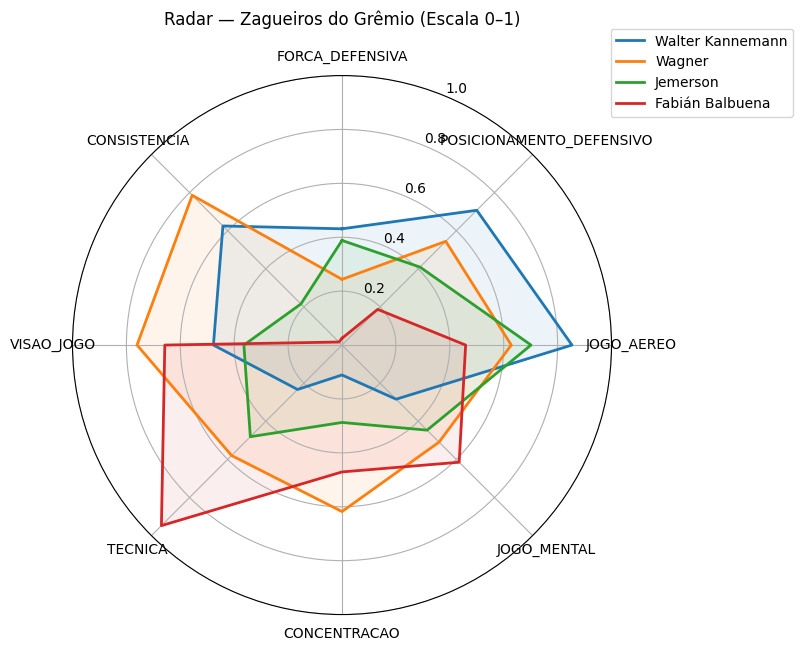

,Player,Age_years,Liga,SUPER_ZAGUEIRO,FORCA_DEFENSIVA,POSICIONAMENTO_DEFENSIVO,JOGO_AEREO,JOGO_MENTAL,CONCENTRACAO,TECNICA,VISAO_JOGO,CONSISTENCIA
314,Walter Kannemann,33,Série A - Brasil,0.481191,0.431316,0.707275,0.853342,0.284055,0.111056,0.233230,0.477108,0.624965
128,Wagner,25,Série A - Brasil,0.476727,0.243850,0.544493,0.628092,0.509265,0.617857,0.579565,0.760631,0.785926
415,Jemerson,32,Série A - Brasil,0.400783,0.388165,0.409311,0.701340,0.446592,0.287191,0.481008,0.364093,0.215674
184,Fabián Balbuena,33,Série A - Brasil,0.323130,0.025142,0.187261,0.458726,0.614876,0.470780,0.947620,0.657522,0.015928


In [105]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Filtra apenas jogadores do Grêmio
# ------------------------------------------------------------
df = wild.copy()

gremio_df = (
    df
    .query("Squad == 'Grêmio'")
    .sort_values("SUPER_ZAGUEIRO", ascending=False)
)

if gremio_df.empty:
    raise ValueError("Nenhum jogador do Grêmio encontrado na base.")

# ------------------------------------------------------------
# Atributos do radar (todos 0–1)
# ------------------------------------------------------------
atributos = [
    "FORCA_DEFENSIVA",
    "POSICIONAMENTO_DEFENSIVO",
    "JOGO_AEREO",
    "JOGO_MENTAL",
    "CONCENTRACAO",
    "TECNICA",
    "VISAO_JOGO",
    "CONSISTENCIA"
]

labels = atributos
num_vars = len(labels)

angles = np.linspace(0, 2*np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig = plt.figure(figsize=(9, 7))
ax = plt.subplot(111, polar=True)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), labels)
ax.set_ylim(0, 1)

for _, row in gremio_df.iterrows():
    vals = [float(row[a]) for a in atributos]
    vals += vals[:1]
    ax.plot(angles, vals, linewidth=2, label=row["Player"])
    ax.fill(angles, vals, alpha=0.08)

plt.title("Radar — Zagueiros do Grêmio (Escala 0–1)", y=1.08)
plt.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1))
plt.show()

# ------------------------------------------------------------
# Tabela final para conferência
# ------------------------------------------------------------
cols_out = ["Player", "Age_years", "Liga", "SUPER_ZAGUEIRO"] + atributos
display(gremio_df[cols_out])


### Célula 33 - Identificação da Mediana do Ranking para Super Zagueiros

A identificação da Mediana nos permite avaliar de maneira mais contundente onde estão localizados os zagueeiros do Gremio no corte de avaliação do universo selecionado.

É possível identificar que tanto Jemmerson como Fabián Balbuena estão abaixo do corte da mediana no Super Zagueiros, dentro do universo selecionado.

In [106]:
# ============================================================
# MEDIANA GLOBAL — SUPER_ZAGUEIRO
# ============================================================

mediana_global = wild["SUPER_ZAGUEIRO"].median()

print("📊 Mediana GLOBAL do SUPER_ZAGUEIRO:")
print(mediana_global)


📊 Mediana GLOBAL do SUPER_ZAGUEIRO:
0.4244299498690274


### Célula 34 - Comparação e inserção na base das informações dos atributos x Medianas dos atributos em cada liga

Nesta célula nós criamos uma comparação por atributo para cada jogador do ranking para identificar se cada um dos seus atributos está abaixo, na mediana ou acima, em relação a mediana dos atributos para cada liga que os jogadores fazem parte.

In [107]:
# ============================================================
# CLASSIFICAÇÃO POR LIGA — ACIMA / NA MEDIANA / ABAIXO
# ============================================================

METRICAS_CLASSIFICACAO = [
    "FORCA_DEFENSIVA",
    "POSICIONAMENTO_DEFENSIVO",
    "JOGO_AEREO",
    "CONCENTRACAO",
    "JOGO_MENTAL",
    "VISAO_JOGO",
    "TECNICA",
    "CONSISTENCIA",
]

LIMIAR = 0.01  # faixa ±10% em torno da mediana

# ------------------------------------------------------------
# 1) Calcular mediana por Liga
# ------------------------------------------------------------
medianas_liga = (
    wild
    .groupby("Liga")[METRICAS_CLASSIFICACAO]
    .median()
    .reset_index()
)

# ------------------------------------------------------------
# 2) Merge das medianas na WILD
# ------------------------------------------------------------
wild = wild.merge(
    medianas_liga,
    on="Liga",
    suffixes=("", "_MED_LIGA"),
    how="left"
)

# ------------------------------------------------------------
# 3) Classificação textual (SEM np.where)
# ------------------------------------------------------------
for m in METRICAS_CLASSIFICACAO:
    col_med = f"{m}_MED_LIGA"
    col_cls = f"{m}_CLASS_LIGA"

    wild[col_cls] = None  # força dtype object

    acima = wild[m] > (wild[col_med] + LIMIAR)
    abaixo = wild[m] < (wild[col_med] - LIMIAR)
    na_mediana = ~(acima | abaixo)

    wild.loc[acima, col_cls] = "ACIMA"
    wild.loc[abaixo, col_cls] = "ABAIXO"
    wild.loc[na_mediana, col_cls] = "NA MEDIANA"

# ------------------------------------------------------------
# 4) Limpeza (opcional)
# ------------------------------------------------------------
wild.drop(
    columns=[f"{m}_MED_LIGA" for m in METRICAS_CLASSIFICACAO],
    inplace=True
)

print("✅ Classificações por liga criadas com sucesso.")

display(
    wild[
        ["player_id", "Liga"] +
        [f"{m}_CLASS_LIGA" for m in METRICAS_CLASSIFICACAO]
    ].head(10)
)


✅ Classificações por liga criadas com sucesso.


,player_id,Liga,FORCA_DEFENSIVA_CLASS_LIGA,POSICIONAMENTO_DEFENSIVO_CLASS_LIGA,JOGO_AEREO_CLASS_LIGA,CONCENTRACAO_CLASS_LIGA,JOGO_MENTAL_CLASS_LIGA,VISAO_JOGO_CLASS_LIGA,TECNICA_CLASS_LIGA,CONSISTENCIA_CLASS_LIGA
0,00242715,League 1 - França,ABAIXO,ACIMA,ACIMA,ABAIXO,ABAIXO,ACIMA,ACIMA,ACIMA
1,0057a058,Liga MX - México,ACIMA,NA MEDIANA,ACIMA,ABAIXO,NA MEDIANA,ABAIXO,ACIMA,ACIMA
2,00963611,Premier League - Inglaterra,ACIMA,ACIMA,ACIMA,ABAIXO,ABAIXO,ABAIXO,ACIMA,ACIMA
3,011d370e,Serie A - Italia,ACIMA,ABAIXO,ABAIXO,ABAIXO,NA MEDIANA,ACIMA,ACIMA,ABAIXO
4,016e419b,MLS - EUA,ACIMA,ACIMA,ACIMA,ACIMA,ACIMA,ABAIXO,ABAIXO,ACIMA
5,01834aa0,Premier League - Inglaterra,ABAIXO,ABAIXO,ACIMA,ABAIXO,ACIMA,ABAIXO,ABAIXO,ABAIXO
6,01a49bd2,Liga - Argentina,ABAIXO,ABAIXO,ACIMA,ACIMA,ACIMA,ABAIXO,ABAIXO,ABAIXO
7,01dc4e41,Série A - Brasil,ACIMA,ACIMA,ABAIXO,ABAIXO,ACIMA,ACIMA,ABAIXO,ABAIXO
8,02fbc447,MLS - EUA,ACIMA,NA MEDIANA,ABAIXO,ABAIXO,ACIMA,ACIMA,ACIMA,ACIMA
9,030d6f99,Serie A - Italia,ABAIXO,ABAIXO,ABAIXO,ABAIXO,ABAIXO,ABAIXO,ABAIXO,ABAIXO


### Célula 35 - Reapresentação do Ranking de Super Zagueiros com a comparação dos zagueiros e as medianas das ligas

Agora com as informações de: abaixo, na mediana ou acima, referente aos atributos dos jogadores em comparação com a mediana desses mesmos atributos para cada liga na qual eles atuam, deixando os dados prontos para visualizações multidimensionais.

Esta etapa prepara a base para:
- análise gráfica,
- construção de radar comparativo,
- comparação entre perfis individuais.

A transformação realizada aqui não altera métricas, apenas organiza a estrutura para leitura analítica.


In [108]:
# ------------------------------------------------------------
# 0) Sanity mínimo: wild precisa ter as métricas e o cadastro canônico
# ------------------------------------------------------------
required_wild = [
    "player_id", "Liga", "Player", "Squad", "Age_years", "info_Continent",
    "SUPER_ZAGUEIRO",
    "FORCA_DEFENSIVA", "POSICIONAMENTO_DEFENSIVO", "JOGO_AEREO",
    "VISAO_JOGO", "TECNICA", "CONSISTENCIA"
]
missing = [c for c in required_wild if c not in wild.columns]
if missing:
    raise ValueError(f"WILD sem colunas obrigatórias: {missing}")

# ------------------------------------------------------------
# 1) Garantir que as colunas *_CLASS_LIGA existem (se não existirem, cria)
#    Observação: usa sua regra atual (mediana ± LIMIAR).
# ------------------------------------------------------------
METRICAS_CLASSIFICACAO = [
    "FORCA_DEFENSIVA",
    "POSICIONAMENTO_DEFENSIVO",
    "JOGO_AEREO",
    "VISAO_JOGO",
    "TECNICA",
    "CONSISTENCIA",
]

LIMIAR = 0.10  # faixa ±0.10 (ajuste depois se quiser)

colunas_class = [f"{m}_CLASS_LIGA" for m in METRICAS_CLASSIFICACAO]
precisa_classificar = any(c not in wild.columns for c in colunas_class)

if precisa_classificar:
    # mediana por liga
    medianas_liga = (
        wild
        .groupby("Liga")[METRICAS_CLASSIFICACAO]
        .median()
        .reset_index()
    )

    # merge medianas
    tmp = wild.merge(medianas_liga, on="Liga", suffixes=("", "_MED_LIGA"), how="left")

    # classificar
    for m in METRICAS_CLASSIFICACAO:
        col_med = f"{m}_MED_LIGA"
        col_cls = f"{m}_CLASS_LIGA"

        tmp[col_cls] = None  # object
        acima = tmp[m] > (tmp[col_med] + LIMIAR)
        abaixo = tmp[m] < (tmp[col_med] - LIMIAR)
        na_mediana = ~(acima | abaixo)

        tmp.loc[acima, col_cls] = "ACIMA"
        tmp.loc[abaixo, col_cls] = "ABAIXO"
        tmp.loc[na_mediana, col_cls] = "NA MEDIANA"

    # limpar colunas de mediana e devolver pro wild
    tmp.drop(columns=[f"{m}_MED_LIGA" for m in METRICAS_CLASSIFICACAO], inplace=True)
    wild = tmp

# ------------------------------------------------------------
# 2) Gerar TOP50 a partir da WILD (não do top50 antigo)
# ------------------------------------------------------------
top50_sulamericanos = (
    wild
    .query("info_Continent == 'South America'")
    .sort_values("SUPER_ZAGUEIRO", ascending=False)
    .head(50)
    .reset_index(drop=True)
)

top50_sulamericanos.index = top50_sulamericanos.index + 1

# ------------------------------------------------------------
# 3) Função de arquétipo (AGORA usa Age_years, não Age)
# ------------------------------------------------------------
def definir_arquetipo(row):
    age = row.get("Age_years")
    sz = row.get("SUPER_ZAGUEIRO")

    if pd.isna(age) or pd.isna(sz):
        return "Sem Dados"

    # 0️⃣ SUPER ZAGUEIRO (prioritária)
    if sz >= 0.60:
        return "Super Zagueiro"

    # 1️⃣ Potencial / Desenvolvimento (AJUSTADO)
    if age <= 24:
        if sz >= 0.53:
            return "Zagueiro com Grande Potencial"
        else:
            return "Zagueiro em Desenvolvimento"

    # 2️⃣ Dominante Defensivo
    if (
        row.get("FORCA_DEFENSIVA_CLASS_LIGA") == "ACIMA" and
        row.get("POSICIONAMENTO_DEFENSIVO_CLASS_LIGA") == "ACIMA" and
        row.get("JOGO_AEREO_CLASS_LIGA") == "ACIMA" and
        row.get("CONSISTENCIA_CLASS_LIGA") != "ABAIXO"
    ):
        return "Dominante Defensivo"

    # 3️⃣ Zagueiro Construtor
    if (
        row.get("VISAO_JOGO_CLASS_LIGA") == "ACIMA" and
        row.get("TECNICA_CLASS_LIGA") == "ACIMA"
    ):
        return "Zagueiro Construtor"

    # 4️⃣ Zagueiro Completo
    if (
        row.get("FORCA_DEFENSIVA_CLASS_LIGA") == "ACIMA" and
        row.get("POSICIONAMENTO_DEFENSIVO_CLASS_LIGA") == "ACIMA" and
        row.get("JOGO_AEREO_CLASS_LIGA") == "ACIMA" and
        row.get("CONSISTENCIA_CLASS_LIGA") == "ACIMA"
    ):
        return "Zagueiro Completo"

    return "Perfil Híbrido"

# ------------------------------------------------------------
# 4) Aplicação + VIEW
# ------------------------------------------------------------
top50_sulamericanos["ARQUETIPO_PRINCIPAL"] = top50_sulamericanos.apply(definir_arquetipo, axis=1)

print("✅ Arquétipo principal definido com sucesso.")
print("Shape:", top50_sulamericanos.shape)

display(
    top50_sulamericanos[
        [
            "Player",
            "Age_years",
            "Squad",
            "Liga",
            "SUPER_ZAGUEIRO",
            "ARQUETIPO_PRINCIPAL",

            "FORCA_DEFENSIVA", "FORCA_DEFENSIVA_CLASS_LIGA",
            "POSICIONAMENTO_DEFENSIVO", "POSICIONAMENTO_DEFENSIVO_CLASS_LIGA",
            "JOGO_AEREO", "JOGO_AEREO_CLASS_LIGA",
            "VISAO_JOGO", "VISAO_JOGO_CLASS_LIGA",
            "TECNICA", "TECNICA_CLASS_LIGA",
            "CONSISTENCIA", "CONSISTENCIA_CLASS_LIGA",
        ]
    ]
)


✅ Arquétipo principal definido com sucesso.
Shape: (50, 64)


,Player,Age_years,Squad,Liga,SUPER_ZAGUEIRO,ARQUETIPO_PRINCIPAL,FORCA_DEFENSIVA,FORCA_DEFENSIVA_CLASS_LIGA,POSICIONAMENTO_DEFENSIVO,POSICIONAMENTO_DEFENSIVO_CLASS_LIGA,JOGO_AEREO,JOGO_AEREO_CLASS_LIGA,VISAO_JOGO,VISAO_JOGO_CLASS_LIGA,TECNICA,TECNICA_CLASS_LIGA,CONSISTENCIA,CONSISTENCIA_CLASS_LIGA
1,Marcos Senesi,28,Bournemouth,Premier League - Inglaterra,0.653726,Super Zagueiro,0.583855,ACIMA,0.799025,ACIMA,0.471182,ABAIXO,0.892033,ACIMA,0.822510,ACIMA,0.864489,ACIMA
2,Nicolás Otamendi,37,Benfica,Primeira Liga - Portugal,0.625983,Super Zagueiro,0.533764,ACIMA,0.725527,ACIMA,0.837710,ACIMA,0.899860,ACIMA,0.911692,ACIMA,0.915627,ACIMA
3,Guillermo Maripán,31,Torino,Serie A - Italia,0.618133,Super Zagueiro,0.690066,ACIMA,0.817494,ACIMA,0.525405,NA MEDIANA,0.524794,ABAIXO,0.447805,ABAIXO,0.890172,ACIMA
4,Fabrício Bruno,28,Cruzeiro,Série A - Brasil,0.617565,Super Zagueiro,0.623268,ACIMA,0.763289,ACIMA,0.666166,ACIMA,0.808201,ACIMA,0.633886,ACIMA,0.947039,ACIMA
5,Alexander Barboza,29,Botafogo (RJ),Série A - Brasil,0.617397,Super Zagueiro,0.580513,ACIMA,0.693497,ACIMA,0.799284,ACIMA,0.817535,ACIMA,0.875526,ACIMA,0.798001,ACIMA
6,Zé Vitor,24,Nacional,Primeira Liga - Portugal,0.589736,Zagueiro com Grande Potencial,0.597902,ACIMA,0.775475,ACIMA,0.779551,ACIMA,0.734140,ACIMA,0.630396,ACIMA,0.771160,ACIMA
7,Gustavo Gómez,31,Palmeiras,Série A - Brasil,0.587607,Dominante Defensivo,0.623451,ACIMA,0.683129,ACIMA,0.750228,ACIMA,0.735764,ACIMA,0.475846,ABAIXO,0.805336,ACIMA
8,Cristian Romero,27,Tottenham,Premier League - Inglaterra,0.586609,Dominante Defensivo,0.574727,ACIMA,0.628413,ACIMA,0.751776,ACIMA,0.682529,ACIMA,0.544247,ABAIXO,0.665893,ACIMA
9,Éder Militão,27,Real Madrid,La Liga - Espanha,0.586112,Dominante Defensivo,0.579237,ACIMA,0.506366,ACIMA,0.606315,ACIMA,0.801233,ACIMA,0.799183,ACIMA,0.591464,ACIMA
10,Willian Machado,28,Ceará,Série A - Brasil,0.583501,Dominante Defensivo,0.522207,ACIMA,0.743707,ACIMA,0.846857,ACIMA,0.623963,ACIMA,0.412139,ABAIXO,0.947039,ACIMA


### Célula 36 - Apresentação da Mediana para FORÇA DEFENSIVA da Série A - Brasil.

Trouxemos a mediana Série A Brasil para entender alguns aspectos, como por exemplo, jogadores como Pedro Henrique do RedBull Bragantino que estão muito bem colocados no ranking Super Zagueiro mas estão abaixo da mediana de Força defensiva.

Não aplicamos nenhum debuff para esses casos, mas é possível pensar em criar, no ranking geral debuffs para jogadores que apesar de constarem bem rankeados apresentarem atributos abaixo da média.

Neste caso, utilizamos esse conceito apenas para ilustração, mas é possível ver também Gabriel Magalhães, último colocado do Ranking Super Zagueiro e cotado para ser titular da Copa do Mundod pelo Brasil com Força Defensiva abaixo da mediana da Premiere League.

Neste caso, vale ainda um estudo pormenorizado dos times que eles jogam, para identificar tendências e a partir daí identificar característica do time ou deficiência do próprio jogador.

In [109]:
# ============================================================
# MEDIANA — FORÇA DEFENSIVA | Série A - Brasil
# ============================================================

liga_alvo = "Série A - Brasil"

mediana_forca_defensiva_brasil = (
    wild
    .query("Liga == @liga_alvo")
    ["FORCA_DEFENSIVA"]
    .median()
)

print(f"📊 Mediana de FORÇA_DEFENSIVA — {liga_alvo}:")
print(round(mediana_forca_defensiva_brasil, 4))


📊 Mediana de FORÇA_DEFENSIVA — Série A - Brasil:
0.2804


### Célula 37 - Consolidação do Vetor Analítico Individual - Ranking Série A

O vetor consolida:
- métricas autorais,
- ajustes contextuais,
- estabilidade estatística,
- controle de outliers.

Esse vetor é a representação matemática do perfil completo do atleta dentro do modelo.


In [110]:

df = wild.copy()

COL_LIGA = "Liga"
COL_ID = "player_id"

# tenta achar coluna de nome do jogador
COL_PLAYER = "Player" if "Player" in df.columns else ("player_name" if "player_name" in df.columns else None)

# tenta achar coluna de posição
COL_POS = "Pos" if "Pos" in df.columns else ("info_pos_recorte" if "info_pos_recorte" in df.columns else None)

# tenta achar coluna de time
COL_SQUAD = "Squad" if "Squad" in df.columns else ("Time" if "Time" in df.columns else ("Squad_x" if "Squad_x" in df.columns else None))

# filtro Série A
serie_a = df[df[COL_LIGA].astype(str).str.strip() == "Série A - Brasil"].copy()

# ranking
serie_a = serie_a.sort_values("SUPER_ZAGUEIRO", ascending=False).reset_index(drop=True)
serie_a["Rank_SerieA"] = serie_a.index + 1

cols_out = ["Rank_SerieA", COL_ID]
if COL_PLAYER: cols_out.append(COL_PLAYER)
if COL_SQUAD: cols_out.append(COL_SQUAD)
if COL_POS: cols_out.append(COL_POS)
cols_out += ["SUPER_ZAGUEIRO","FORCA_DEFENSIVA","POSICIONAMENTO_DEFENSIVO","JOGO_AEREO","CONCENTRACAO","JOGO_MENTAL","TECNICA","VISAO_JOGO","CONSISTENCIA"]

# mantém só as colunas que existem
cols_out = [c for c in cols_out if c in serie_a.columns]

serie_a[cols_out].head(50)


,Rank_SerieA,player_id,Player,Squad,Pos,SUPER_ZAGUEIRO,FORCA_DEFENSIVA,POSICIONAMENTO_DEFENSIVO,JOGO_AEREO,CONCENTRACAO,JOGO_MENTAL,TECNICA,VISAO_JOGO,CONSISTENCIA
0,1,470d197b,Fabrício Bruno,Cruzeiro,CB,0.617565,0.623268,0.763289,0.666166,0.848240,0.315424,0.633886,0.808201,0.947039
1,2,b1805c80,Alexander Barboza,Botafogo (RJ),CB,0.617397,0.580513,0.693497,0.799284,0.480710,0.349711,0.875526,0.817535,0.798001
2,3,d5ce52a5,Gustavo Gómez,Palmeiras,CB,0.587607,0.623451,0.683129,0.750228,0.679106,0.429910,0.475846,0.735764,0.805336
3,4,afb23fa3,Willian Machado,Ceará,CB,0.583501,0.522207,0.743707,0.846857,0.651446,0.423599,0.412139,0.623963,0.947039
4,5,d60cf08d,João Victor,Vasco da Gama,CB,0.560725,0.561491,0.487604,0.857734,0.592361,0.414829,0.758225,0.700230,0.606041
5,6,f2c1300a,Vitor Hugo,Atlético Mineiro,CB,0.546734,0.557604,0.588955,0.768613,0.782967,0.355710,0.435958,0.779371,0.552784
6,7,fa066690,Gustavo Henrique,Corinthians,CB,0.541510,0.409920,0.449162,0.887423,0.990076,0.464372,0.699542,0.603127,0.769736
7,8,d1c8df97,Victor Gabriel,Internacional,CB,0.520791,0.517515,0.624266,0.802641,0.244043,0.392976,0.638332,0.572268,0.371164
8,9,e1524457,José Sabino,São Paulo,CB,0.520176,0.404626,0.639359,0.564003,0.436777,0.396568,0.695268,0.865147,0.735059
9,10,4322e5d7,Pedro Henrique,RB Bragantino,CB,0.519905,0.269710,0.561792,0.630464,0.785065,0.480846,0.723506,0.875715,0.900281


### Célula 38 — Comparação Estratégica: Força Defensiva vs Índice SUPER_ZAGUEIRO

Nesta etapa construímos uma visualização bidimensional para posicionar os zagueiros sul-americanos em relação a dois eixos fundamentais do modelo:

- **FORÇA_DEFENSIVA** (atributo específico)
- **SUPER_ZAGUEIRO** (índice sintético consolidado)

A visualização considera:

- Top 20 zagueiros sul-americanos pelo índice geral;
- Inclusão estratégica dos zagueiros do Grêmio;
- Destaque visual específico para o grupo do Grêmio.

O objetivo não é apenas ranquear, mas **posicionar perfis relativos**, permitindo identificar:

- jogadores com alta performance defensiva específica;
- jogadores com performance global elevada;
- casos de divergência entre atributo isolado e índice consolidado.

Este gráfico serve como ferramenta analítica comparativa, evidenciando posicionamento estratégico no espaço de desempenho.



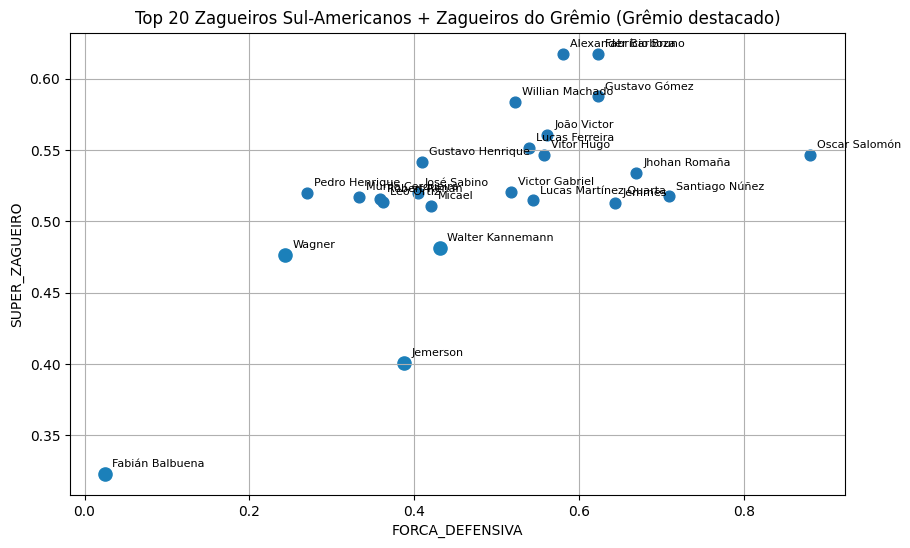

,player_id,Player,Squad,Liga,SUPER_ZAGUEIRO,FORCA_DEFENSIVA
0,470d197b,Fabrício Bruno,Cruzeiro,Série A - Brasil,0.617565,0.623268
1,b1805c80,Alexander Barboza,Botafogo (RJ),Série A - Brasil,0.617397,0.580513
2,d5ce52a5,Gustavo Gómez,Palmeiras,Série A - Brasil,0.587607,0.623451
3,afb23fa3,Willian Machado,Ceará,Série A - Brasil,0.583501,0.522207
4,d60cf08d,João Victor,Vasco da Gama,Série A - Brasil,0.560725,0.561491
5,27aecc44,Lucas Ferreira,Defensa y Just,Liga - Argentina,0.551536,0.538971
6,92c77992,Oscar Salomón,Platense,Liga - Argentina,0.546833,0.880226
7,f2c1300a,Vitor Hugo,Atlético Mineiro,Série A - Brasil,0.546734,0.557604
8,fa066690,Gustavo Henrique,Corinthians,Série A - Brasil,0.541510,0.409920
9,4e32c2d6,Jhohan Romaña,San Lorenzo,Liga - Argentina,0.533897,0.669631


In [111]:

import matplotlib.pyplot as plt
import numpy as np

df = wild.copy()

COL_LIGA = "Liga"
COL_ID = "player_id"
COL_PLAYER = "Player" if "Player" in df.columns else ("player_name" if "player_name" in df.columns else None)
COL_POS = "Pos" if "Pos" in df.columns else ("info_pos_recorte" if "info_pos_recorte" in df.columns else None)
COL_SQUAD = "Squad" if "Squad" in df.columns else ("Time" if "Time" in df.columns else None)

# --- define ligas sul-americanas por texto (edite se quiser)
paises_sa = ["Brasil","Argentina","Uruguai","Chile","Colombia","Paraguai","Peru","Ecuador","Bolivia","Venezuela"]
mask_sa = df[COL_LIGA].astype(str).str.contains("|".join(paises_sa), case=False, na=False)
sa = df[mask_sa].copy()

# --- filtra só zagueiros se tiver coluna de posição
if COL_POS:
    sa = sa[sa[COL_POS].astype(str).str.contains("CB", case=False, na=False)].copy()

# --- pega Top 20 por SUPER_ZAGUEIRO
top20 = sa.sort_values("SUPER_ZAGUEIRO", ascending=False).head(20).copy()

# --- pega 4 zagueiros do Grêmio (por time) ou por IDs se preferir
gremio_ids = ["5b37f2f8","25b28b59","7cab69b5"]  # você citou 3 IDs (Kannemann, Wagner, Jemerson) — se tiver o 4º, coloque aqui
# tenta achar 4º via time "Grêmio" se existir coluna de time
gremio = df.iloc[0:0].copy()
if COL_SQUAD:
    gremio = df[df[COL_SQUAD].astype(str).str.contains("Grêmio", case=False, na=False)].copy()
    if COL_POS:
        gremio = gremio[gremio[COL_POS].astype(str).str.contains("CB", case=False, na=False)].copy()
    gremio = gremio.sort_values("SUPER_ZAGUEIRO", ascending=False).head(4).copy()

# garante inclusão dos IDs informados (mesmo que não apareçam no filtro do time)
gremio_by_id = df[df[COL_ID].isin(gremio_ids)].copy()
gremio = pd.concat([gremio, gremio_by_id], ignore_index=True).drop_duplicates(subset=[COL_ID])

# --- dataset final: top20 + gremio
plot_df = pd.concat([top20, gremio], ignore_index=True).drop_duplicates(subset=[COL_ID])

# --- marca quem é Grêmio (por time OU por IDs)
is_gremio = np.zeros(len(plot_df), dtype=bool)
if COL_SQUAD:
    is_gremio |= plot_df[COL_SQUAD].astype(str).str.contains("Grêmio", case=False, na=False).values
is_gremio |= plot_df[COL_ID].isin(gremio_ids).values

# --- eixos do scatter
x = plot_df["FORCA_DEFENSIVA"].astype(float)
y = plot_df["SUPER_ZAGUEIRO"].astype(float)

plt.figure(figsize=(10,6))
# não-Grêmio
plt.scatter(x[~is_gremio], y[~is_gremio], s=60)
# Grêmio (azul solicitado)
plt.scatter(x[is_gremio], y[is_gremio], s=90, color="#1b80ba")

plt.xlabel("FORCA_DEFENSIVA")
plt.ylabel("SUPER_ZAGUEIRO")
plt.title("Top 20 Zagueiros Sul-Americanos + Zagueiros do Grêmio (Grêmio destacado)")

# rótulos (nome ou id)
label_col = COL_PLAYER if COL_PLAYER else COL_ID
for _, r in plot_df.iterrows():
    plt.annotate(
        str(r[label_col]),
        (float(r["FORCA_DEFENSIVA"]), float(r["SUPER_ZAGUEIRO"])),
        fontsize=8,
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.grid(True)
plt.show()

plot_df[[c for c in [COL_ID, COL_PLAYER, COL_SQUAD, COL_LIGA, "SUPER_ZAGUEIRO","FORCA_DEFENSIVA"] if c and c in plot_df.columns]] \
    .sort_values("SUPER_ZAGUEIRO", ascending=False)


### Célula 39 — Radar Comparativo: Zagueiros do Grêmio vs Melhor da Série A

Nesta etapa construímos um gráfico radar comparando:

- os zagueiros do Grêmio,
- o melhor zagueiro da Série A segundo o índice **SUPER_ZAGUEIRO**.

As oito dimensões do modelo (normalizadas entre 0 e 1) permitem visualizar diferenças estruturais de perfil, destacando:

- pontos fortes relativos,
- assimetrias técnicas,
- lacunas competitivas em relação à principal referência da liga.

O radar traduz o índice sintético em leitura multidimensional clara e comparável.


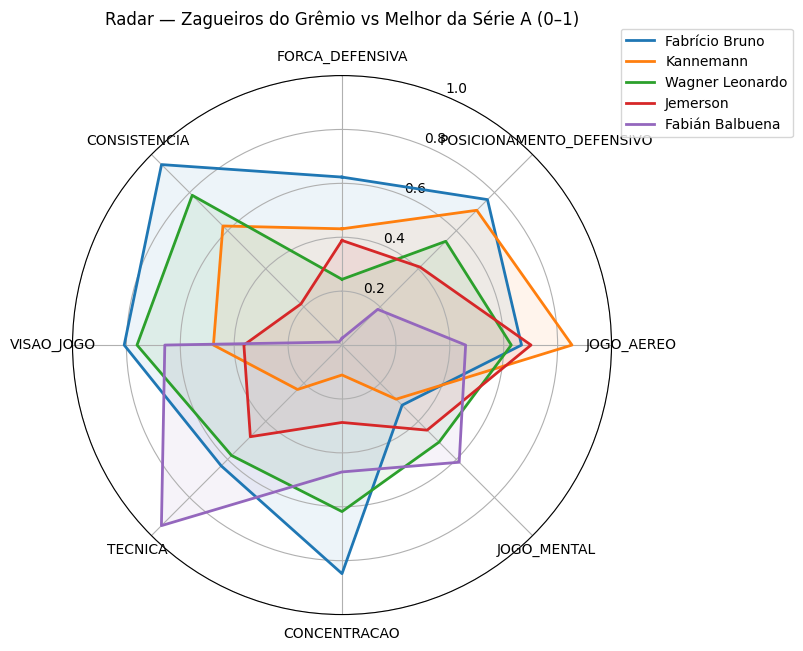

,Player,player_id,FORCA_DEFENSIVA,POSICIONAMENTO_DEFENSIVO,JOGO_AEREO,JOGO_MENTAL,CONCENTRACAO,TECNICA,VISAO_JOGO,CONSISTENCIA,Liga
0,Fabrício Bruno,470d197b,0.623268,0.763289,0.666166,0.315424,0.848240,0.633886,0.808201,0.947039,Série A - Brasil
1,Walter Kannemann,5b37f2f8,0.431316,0.707275,0.853342,0.284055,0.111056,0.233230,0.477108,0.624965,Série A - Brasil
2,Jemerson,7cab69b5,0.388165,0.409311,0.701340,0.446592,0.287191,0.481008,0.364093,0.215674,Série A - Brasil
3,Wagner,25b28b59,0.243850,0.544493,0.628092,0.509265,0.617857,0.579565,0.760631,0.785926,Série A - Brasil
4,Fabián Balbuena,3626f7d9,0.025142,0.187261,0.458726,0.614876,0.470780,0.947620,0.657522,0.015928,Série A - Brasil


In [121]:
import numpy as np
import matplotlib.pyplot as plt

df = wild.copy()

players_ids = {
    "Fabrício Bruno": "470d197b",
    "Kannemann": "5b37f2f8",
    "Wagner Leonardo": "25b28b59",
    "Jemerson": "7cab69b5",
    "Fabián Balbuena": "3626f7d9"
}

# atributos do radar (todos 0-1 no seu modelo)
atributos = [
    "FORCA_DEFENSIVA",
    "POSICIONAMENTO_DEFENSIVO",
    "JOGO_AEREO",
    "JOGO_MENTAL",
    "CONCENTRACAO",
    "TECNICA",
    "VISAO_JOGO",
    "CONSISTENCIA"
]

# ------------------------------------------------------------
# 1. Seleção dos dados
# ------------------------------------------------------------

rad = df[df["player_id"].isin(list(players_ids.values()))].copy()

# sanity check
faltando = [
    name for name, pid in players_ids.items()
    if pid not in set(rad["player_id"])
]
if faltando:
    print("⚠️ IDs não encontrados na wild:", faltando)

# ------------------------------------------------------------
# 2. Preparação do Radar
# ------------------------------------------------------------

labels = atributos
num_vars = len(labels)

angles = np.linspace(0, 2*np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # fecha o radar

fig = plt.figure(figsize=(9, 7))
ax = plt.subplot(111, polar=True)

# configuração do eixo
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), labels)
ax.set_ylim(0, 1)

# ------------------------------------------------------------
# 3. Plotagem
# ------------------------------------------------------------

for nome, pid in players_ids.items():
    row = rad[rad["player_id"] == pid]
    if row.empty:
        continue

    vals = [float(row[a].iloc[0]) for a in atributos]
    vals += vals[:1]

    ax.plot(angles, vals, linewidth=2, label=nome)
    ax.fill(angles, vals, alpha=0.08)

plt.title("Radar — Zagueiros do Grêmio vs Melhor da Série A (0–1)", y=1.08)
plt.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1))
plt.show()

# ------------------------------------------------------------
# 4. Tabela comparativa final
# ------------------------------------------------------------

rad_out_cols = (
    ["Player", "player_id"] +
    atributos +
    (["Liga"] if "Liga" in rad.columns else [])
)

display(
    rad[rad_out_cols]
    .sort_values("FORCA_DEFENSIVA", ascending=False)
    .reset_index(drop=True)
)


### Célula 40 — Construção Teórica por Domínio Máximo (Zagueiro Ideal)

O **Zagueiro Ideal** é uma entidade teórica construída a partir do **melhor valor observado em cada atributo do modelo**, considerando apenas jogadores elegíveis por tempo em campo.

Cada dimensão do Zagueiro Ideal corresponde ao **máximo empírico real** registrado na base, e não a médias, percentis agregados ou valores simulados.

Essa construção estabelece um teto de referência, permitindo avaliar a distância entre jogadores reais e o melhor desempenho observado em cada atributo.

In [122]:
import pandas as pd
import numpy as np

df = wild.copy()

COL_ID = "player_id"
COL_PLAYER = "Player"
COL_SQUAD = "Squad"
COL_LIGA = "Liga"
COL_POS = "Pos" if "Pos" in df.columns else ("info_pos_recorte" if "info_pos_recorte" in df.columns else None)

MIN_PCTL_90S = 0.60

atributos = [
    "FORCA_DEFENSIVA",
    "POSICIONAMENTO_DEFENSIVO",
    "JOGO_AEREO",
    "JOGO_MENTAL",
    "CONCENTRACAO",
    "TECNICA",
    "VISAO_JOGO",
    "CONSISTENCIA"
]

base = df[
    (df[COL_LIGA] == "Série A - Brasil") &
    (df["PT_PCTL_90s"] >= MIN_PCTL_90S)
].copy()

if COL_POS:
    base = base[base[COL_POS].str.contains("CB", case=False, na=False)]

ideal_vals = {}
ideal_ids = {}
ideal_players = {}
ideal_squads = {}

for a in atributos:
    idx = base[a].idxmax()
    ideal_vals[a] = float(base.loc[idx, a])
    ideal_ids[a] = base.loc[idx, COL_ID]
    ideal_players[a] = base.loc[idx, COL_PLAYER]
    ideal_squads[a] = base.loc[idx, COL_SQUAD]

zagueiro_ideal = pd.DataFrame([{
    "player_id": "IDEAL_MAX",
    "Player": "ZAGUEIRO IDEAL (MAX)",
    "Squad": "-",
    **ideal_vals
}])

zagueiro_ideal


,player_id,Player,Squad,FORCA_DEFENSIVA,POSICIONAMENTO_DEFENSIVO,JOGO_AEREO,JOGO_MENTAL,CONCENTRACAO,TECNICA,VISAO_JOGO,CONSISTENCIA
0,IDEAL_MAX,ZAGUEIRO IDEAL (MAX),-,0.663494,0.763289,0.887423,0.587934,0.990076,0.980289,0.976275,0.947039


### Célula 41 - Composição do Zagueiro Ideal

Para garantir transparência e interpretabilidade do modelo, cada atributo que compõe o Zagueiro Ideal é associado ao jogador real que apresentou o maior valor naquela dimensão.

Essa etapa permite:
- identificar quais jogadores dominam atributos específicos;
- evitar interpretações abstratas do ideal;
- demonstrar que o modelo está ancorado em dados reais.

In [114]:
# ============================================================
# TABELA 2 — JOGADORES DOMINANTES POR ATRIBUTO
# ============================================================

montagem_ideal = pd.DataFrame({
    "Atributo": atributos,
    "player_id": [ideal_ids[a] for a in atributos],
    "Player": [ideal_players[a] for a in atributos],
    "Squad": [ideal_squads[a] for a in atributos],
    "Valor": [ideal_vals[a] for a in atributos]
})

montagem_ideal


,Atributo,player_id,Player,Squad,Valor
0,FORCA_DEFENSIVA,f648b2e1,Gastón Ávila,Fortaleza,0.663494
1,POSICIONAMENTO_DEFENSIVO,470d197b,Fabrício Bruno,Cruzeiro,0.763289
2,JOGO_AEREO,fa066690,Gustavo Henrique,Corinthians,0.887423
3,JOGO_MENTAL,e2a29d9d,Rafael Thyere,Sport Recife,0.587934
4,CONCENTRACAO,fa066690,Gustavo Henrique,Corinthians,0.990076
5,TECNICA,7483d9f9,André Ramalho,Corinthians,0.980289
6,VISAO_JOGO,53834fa2,Leo Ortiz,Flamengo,0.976275
7,CONSISTENCIA,341cadaf,Jemmes,Mirassol,0.947039


### Célula 42 - Comparação com os Zagueiros do Grêmio

A partir das métricas já explicadas anteriormente, apresentamos os zagueiros do Gremio.

O objetivo desta análise não é ranquear jogadores, mas:
- identificar distâncias relativas em relação ao ideal;
- destacar pontos fortes e fragilidades individuais;
- evidenciar diferenças de perfil dentro da mesma posição.

In [119]:
# ============================================================
# TABELA 3 — ZAGUEIROS DO GRÊMIO
# ============================================================

gremio_ids = [
    "5b37f2f8",  # Kannemann
    "25b28b59",  # Wagner Leonardo
    "7cab69b5",   # Jemerson
    "3626f7d9"   #Fabián Balbuena
]

gremio_df = df[df[COL_ID].isin(gremio_ids)].copy()

tabela_gremio = gremio_df[
    ["player_id", "Player", "Squad"] + atributos
].sort_values("Player")

tabela_gremio


,player_id,Player,Squad,FORCA_DEFENSIVA,POSICIONAMENTO_DEFENSIVO,JOGO_AEREO,JOGO_MENTAL,CONCENTRACAO,TECNICA,VISAO_JOGO,CONSISTENCIA
184,3626f7d9,Fabián Balbuena,Grêmio,0.025142,0.187261,0.458726,0.614876,0.470780,0.947620,0.657522,0.015928
415,7cab69b5,Jemerson,Grêmio,0.388165,0.409311,0.701340,0.446592,0.287191,0.481008,0.364093,0.215674
128,25b28b59,Wagner,Grêmio,0.243850,0.544493,0.628092,0.509265,0.617857,0.579565,0.760631,0.785926
314,5b37f2f8,Walter Kannemann,Grêmio,0.431316,0.707275,0.853342,0.284055,0.111056,0.233230,0.477108,0.624965


### Célula 43 - Leitura do Radar Comparativo

O gráfico radar sintetiza visualmente a comparação entre o Zagueiro Ideal e os zagueiros analisados.

A leitura correta do radar deve considerar:
- não a área total, mas os desbalanceamentos entre atributos;
- aproximações parciais ao ideal;
- compensações existentes entre diferentes dimensões do jogo.

O radar funciona como ferramenta de análise de perfil, não como ranking visual.


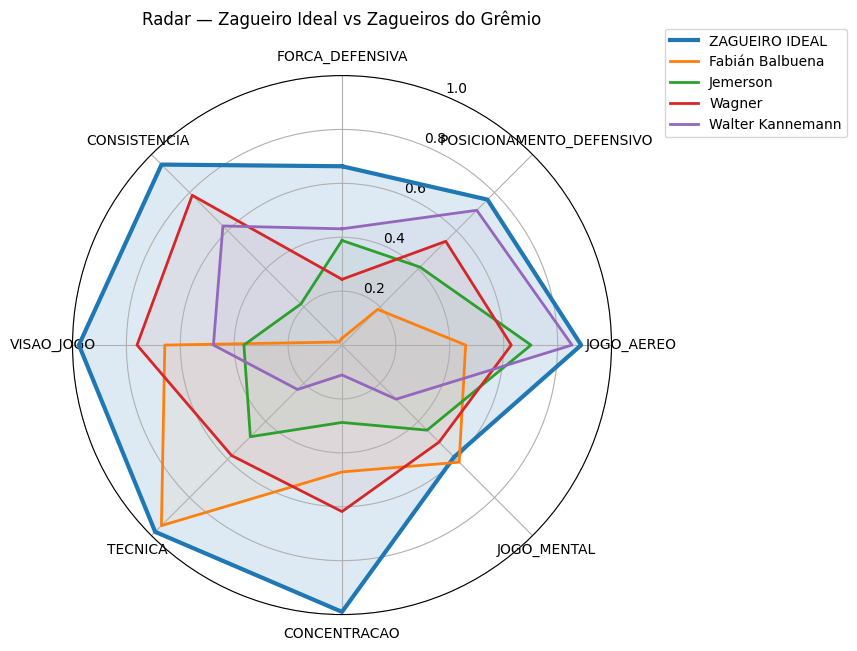

In [120]:
# ============================================================
# RADAR — ZAGUEIRO IDEAL vs ZAGUEIROS DO GRÊMIO
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

radar_df = pd.concat(
    [zagueiro_ideal.assign(label="ZAGUEIRO IDEAL")] +
    [tabela_gremio.assign(label=tabela_gremio["Player"])],
    ignore_index=True
)

labels = atributos
angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

fig = plt.figure(figsize=(9, 7))
ax = plt.subplot(111, polar=True)
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), labels)
ax.set_ylim(0, 1)

for _, r in radar_df.iterrows():
    values = [float(r[a]) for a in atributos]
    values += values[:1]

    if r["label"] == "ZAGUEIRO IDEAL":
        ax.plot(angles, values, linewidth=3, label="ZAGUEIRO IDEAL")
        ax.fill(angles, values, alpha=0.15)
    else:
        ax.plot(angles, values, linewidth=2, label=r["label"])
        ax.fill(angles, values, alpha=0.06)

plt.title("Radar — Zagueiro Ideal vs Zagueiros do Grêmio", y=1.08)
plt.legend(loc="upper right", bbox_to_anchor=(1.45, 1.1))
plt.show()


### Célula 44 - Gráfico de Dispersão com Jogadores do Gremio e Jogadores Sugeridos

O gráfico de dispersão consegue apresentar de maneira bastante direta o posicionamento dos jogadores sugeridos e comparar com o posicionamento dos jogadores do Grêmio.

Foi escolhido neste momento o atributo super zagueiro para o eixo X e a idade dos jogadores para o eixo Y.

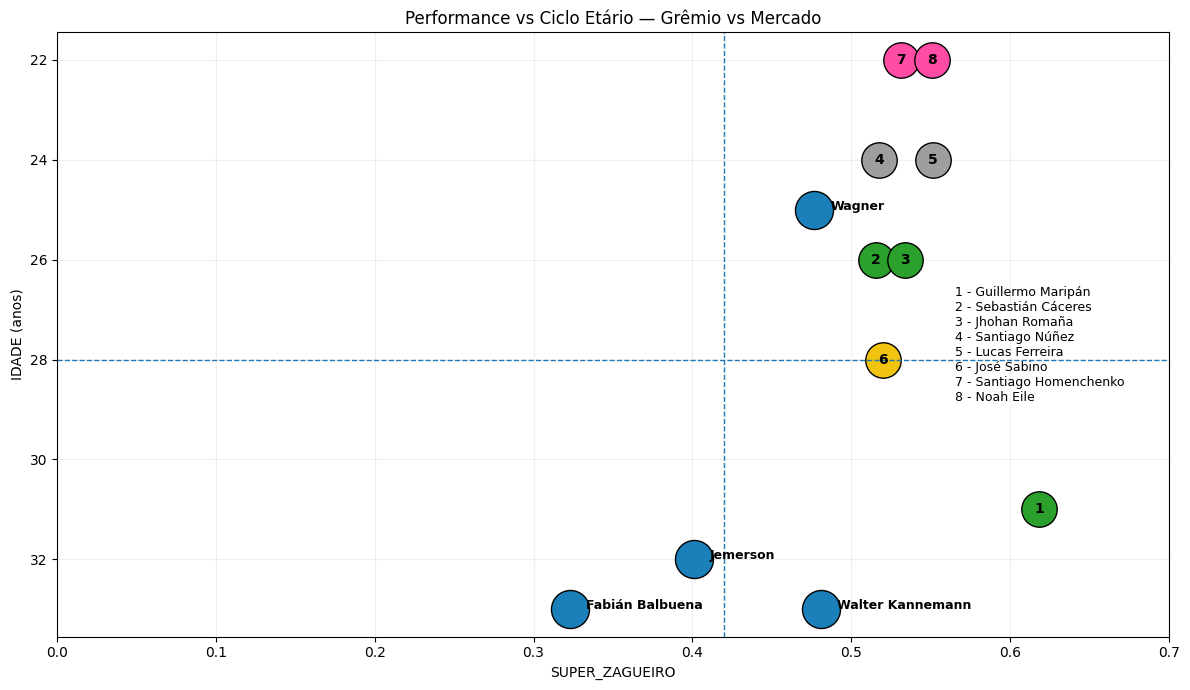

In [117]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

df = wild.copy()

COL_ID = "player_id"
COL_PLAYER = "Player"
COL_SQUAD = "Squad"
COL_AGE = "Age_years"

# -----------------------------
# Grupos (ORDEM IMPORTA)
# -----------------------------
grupo_verde = [
    "d9764034",  # Maripan (1)
    "7091c68e",  # Cáceres (2)
    "4e32c2d6"   # Romaña (3)
]

grupo_cinza = [
    "da0fc816",  # Santiago Nunez (4)
    "27aecc44"   # Lucas Ferreira (5)
]

grupo_amarelo = [
    "e1524457"   # José Sabino (6)
]

grupo_rosa = [
    "d9f9ab8d",  # Homenchenko (7)
    "e1574c2d"   # Noah Eile (8)
]

todos_externos = grupo_verde + grupo_cinza + grupo_amarelo + grupo_rosa

# -----------------------------
# Dados
# -----------------------------
gremio = df[df[COL_SQUAD].astype(str).str.contains("Grêmio", case=False, na=False)].copy()
externos = df[df[COL_ID].isin(todos_externos)].copy()

# -----------------------------
# Função: reordenar subset pela ordem da lista de IDs
# -----------------------------
def ordenar_por_lista(subset: pd.DataFrame, ids: list) -> pd.DataFrame:
    ordem = {pid: i for i, pid in enumerate(ids)}
    return subset.assign(_ord=subset[COL_ID].map(ordem)).sort_values("_ord").drop(columns="_ord")

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(12,7))

# --- Grêmio (sem número, com nome)
ax.scatter(
    gremio["SUPER_ZAGUEIRO"].astype(float),
    gremio[COL_AGE].astype(float),
    s=750,
    color="#1b80ba",
    edgecolor="black",
    linewidth=1,
    zorder=3
)

for _, r in gremio.iterrows():
    ax.text(
        float(r["SUPER_ZAGUEIRO"]) + 0.01,
        float(r[COL_AGE]),
        str(r[COL_PLAYER]),
        fontsize=9,
        fontweight="bold"
    )

# -----------------------------
# Função para plotar grupo numerado + criar legenda
# -----------------------------
legenda = []

def plot_grupo(ids, cor, numero_inicial):
    global legenda
    subset = externos[externos[COL_ID].isin(ids)].copy()
    subset = ordenar_por_lista(subset, ids).reset_index(drop=True)

    for i, (_, r) in enumerate(subset.iterrows()):
        n = numero_inicial + i

        ax.scatter(
            float(r["SUPER_ZAGUEIRO"]),
            float(r[COL_AGE]),
            s=650,
            color=cor,
            edgecolor="black",
            linewidth=1,
            zorder=2
        )

        ax.text(
            float(r["SUPER_ZAGUEIRO"]),
            float(r[COL_AGE]),
            str(n),
            ha="center",
            va="center",
            fontsize=10,
            fontweight="bold"
        )

        legenda.append(f"{n} - {r[COL_PLAYER]}")

    return numero_inicial + len(subset)

# -----------------------------
# Cores (rosa REAL)
# -----------------------------
COR_VERDE   = "#2ca02c"
COR_CINZA   = "#9e9e9e"
COR_AMARELO = "#f1c40f"
COR_ROSA    = "#ff4da6"   # rosa de verdade (não vermelho)

# -----------------------------
# Plot grupos na ordem pedida
# -----------------------------
num = 1
num = plot_grupo(grupo_verde,   COR_VERDE,   num)
num = plot_grupo(grupo_cinza,   COR_CINZA,   num)
num = plot_grupo(grupo_amarelo, COR_AMARELO, num)
num = plot_grupo(grupo_rosa,    COR_ROSA,    num)

# -----------------------------
# Cortes
# -----------------------------
ax.axvline(0.42, linestyle="--", linewidth=1)
ax.axhline(28, linestyle="--", linewidth=1)

ax.invert_yaxis()
ax.set_xlim(0, 0.70)

ax.set_xlabel("SUPER_ZAGUEIRO")
ax.set_ylabel("IDADE (anos)")
ax.set_title("Performance vs Ciclo Etário — Grêmio vs Mercado")

ax.grid(alpha=0.2)

# -----------------------------
# Legenda lateral (numeração -> nome)
# -----------------------------
texto_legenda = "\n".join(legenda)

fig.text(
    0.80, 0.50,
    texto_legenda,
    fontsize=9,
    va="center"
)

plt.tight_layout()
plt.show()
